# AAV2 / AAV5 / AAV9 -- classic MLP weights recovery + top-500 GT landscape + per-variant weight breakdown

For each of the three real datasets, this notebook:

1. Loads the previously-exported `F_viab` / `J_viab` (`lib/{name}_F_viab_mlp.npy` /
   `lib/{name}_J_viab_mlp.npy`) -- the effective single-site/pairwise profile already
   recovered from that dataset's `model_mlp` via a single/double-mutant scan, in the
   dataset's own `AAV{N}_profile_model.ipynb`.
2. Trains a **fresh** classic `ProfileMLP` directly on that dataset's real, noisy `target`
   (which is itself a **log enrichment**, not an abstract score).
3. **Weights recovery**: re-extracts `F_hat`/`J_hat` from this fresh MLP with the same
   mutant-scan method, and compares it against the loaded `F_viab`/`J_viab` reference.
   (Caveat: with the default `seed=0` this is a near-deterministic replay of the *same*
   training run the reference came from, not an independent one -- pass a different `seed`
   to `run_dataset`/`train_mlp` for a genuine robustness check.)
4. **Top-500 GT landscape check**: exhaustively evaluates EVERY one of the `20**7` possible
   sequences with the fresh MLP (no sampling), and sees where the 500 real held-out
   sequences with the highest actual `target` land in that full predicted-log-enrichment
   landscape.
5. **Per-variant weight breakdown**: for the top-5 real held-out variants, plots `F_viab`
   vs. `F_hat` side by side with the amino acid THIS variant actually uses at each position
   boxed in red, plus a grid of every pairwise `J_hat[i, j]` with the (amino acid at i, amino
   acid at j) cell this variant uses boxed in red -- so you can see exactly which weights
   this specific sequence's predicted log enrichment is built from.

Everything below is broken into small, independently-callable functions (`load_dataset`,
`train_mlp`, `weights_recovery`, `landscape_check`, `plot_F_comparison_for_variant`,
`plot_J_grid_for_variant`, `analyze_top_variants`, ...) -- `run_dataset(name)` just chains
them with sensible defaults; call any piece on its own for a one-off look.


### Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split

from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_teacher_weights, plot_topk_recovery

import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

num_positions   = 7
num_amino_acids = len(AA_LABELS)
assert num_amino_acids == 20
print(f"num_positions={num_positions}  num_amino_acids={num_amino_acids}")


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]
num_positions=7  num_amino_acids=20


### Model + training + extraction primitives

In [2]:
class ProfileMLP(nnx.Module):
    """MLP over the one-hot encoded per-position sequence (L=7 x A=20 -> 140 indicator
    features) -> scalar predicted log enrichment. Same architecture used in
    AAV{2,5,9}_profile_model.ipynb."""

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


def extract_effective_FJ_mlp(model, backgrounds, L=num_positions, A=num_amino_acids, batch_size=8192):
    """Single- and double-mutant scan -- recovers the model's effective (A, L) single-site
    F_hat and (L, L, A, A) pairwise J_hat, in predicted-log-enrichment units."""
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    pairs    = [(i, j) for i in range(L) for j in range(i + 1, L)]
    n_pairs  = len(pairs)
    n_double = M * n_pairs * A * A
    double_mutants = np.repeat(backgrounds, n_pairs * A * A, axis=0)
    pair_pattern   = np.repeat(np.arange(n_pairs), A * A)
    aai_block      = np.repeat(np.arange(A), A)
    aaj_block      = np.tile(np.arange(A), A)
    i_of_pair      = np.array([p[0] for p in pairs])
    j_of_pair      = np.array([p[1] for p in pairs])
    tiled_i        = np.tile(i_of_pair[pair_pattern], M)
    tiled_j        = np.tile(j_of_pair[pair_pattern], M)
    tiled_aai      = np.tile(np.tile(aai_block, n_pairs), M)
    tiled_aaj      = np.tile(np.tile(aaj_block, n_pairs), M)
    rows           = np.arange(n_double)
    double_mutants[rows, tiled_i] = tiled_aai
    double_mutants[rows, tiled_j] = tiled_aaj

    x_all = np.concatenate([backgrounds, single_mutants, double_mutants], axis=0)

    enrichment_chunks = []
    for start in range(0, x_all.shape[0], batch_size):
        chunk_oh = np.eye(A, dtype=np.float32)[x_all[start : start + batch_size]].reshape(-1, L * A)
        enrichment_chunks.append(np.asarray(predict_log_enrichment(model, jnp.asarray(chunk_oh))))
    enrichment = np.concatenate(enrichment_chunks)

    mean_enrichment   = enrichment.mean()
    single_enrichment = enrichment[M : M + n_single].reshape(M, L, A)
    double_enrichment = enrichment[M + n_single :].reshape(M, n_pairs, A, A)

    F_flat = single_enrichment.mean(axis=0) - mean_enrichment
    F_hat  = F_flat.T.astype(np.float32)

    double_avg = double_enrichment.mean(axis=0)
    J_hat = np.full((L, L, A, A), np.nan, dtype=np.float32)
    for k, (i, j) in enumerate(pairs):
        delta_ij    = double_avg[k] - mean_enrichment - F_flat[i][:, None] - F_flat[j][None, :]
        J_hat[i, j] = delta_ij
        J_hat[j, i] = delta_ij.T
    return F_hat, J_hat


@jax.jit
def _onehot_chunk(idx, L=num_positions, A=num_amino_acids):
    """Decode a linear index in [0, A**L) into its base-A digit sequence, one-hot encode it."""
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    seq_oh = jnp.eye(A, dtype=jnp.float32)[seq].reshape(seq.shape[0], -1)
    return seq, seq_oh


def onehot_seqs(seq, A=num_amino_acids):
    return jnp.eye(A, dtype=jnp.float32)[seq].reshape(seq.shape[0], -1)


### Per-dataset pipeline pieces (data, splits, weights recovery, landscape check)

In [3]:
def load_dataset(name):
    """CSV -> df, (N, L) raw amino-acid index matrix, (N,) real target (log enrichment),
    (N, L*A) one-hot."""
    df = pd.read_csv(f"{name}.csv")
    lut = np.zeros(256, dtype=np.int64)
    for i, aa in enumerate(AA_LABELS):
        lut[ord(aa)] = i
    seq_bytes  = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
    seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)
    target     = df["target"].to_numpy()
    seq_oh     = np.eye(num_amino_acids, dtype=np.float32)[seq_matrix].reshape(len(df), -1)
    return df, seq_matrix, target, seq_oh


def load_reference_weights(name):
    F = np.load(os.path.join("..", "..", "lib", f"{name}_F_viab_mlp.npy"))
    J = np.load(os.path.join("..", "..", "lib", f"{name}_J_viab_mlp.npy"))
    return F, J


def make_splits(seq_oh, target, seed=0, val_frac=0.15):
    idx_train, idx_test = train_test_split(np.arange(len(target)), test_size=0.5, random_state=seed)
    y_train, y_test       = target[idx_train], target[idx_test]
    X_train_full, X_test  = seq_oh[idx_train], seq_oh[idx_test]
    Xtr, ytr, Xva, yva    = split_train_val(X_train_full, y_train, val_frac=val_frac, seed=seed)
    return idx_train, idx_test, Xtr, ytr, Xva, yva, X_test, y_test


def train_mlp(Xtr, ytr, Xva, yva, seed=0, **kwargs):
    return train_profile_mlp(Xtr, ytr, Xva, yva, seed=seed, **kwargs)


def plot_training_curve(hist, name):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(hist["train_loss"], label="train MSE")
    ax.plot(hist["val_loss"], label="val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log enrichment)"); ax.set_title(f"{name}: training curve")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
    fig.tight_layout(); plt.show()


def weights_recovery(model, seq_matrix, F_ref, J_ref, seed=0, M_backgrounds=256, plot=True, name=""):
    """Extracts F_hat/J_hat from `model` via a small (M_backgrounds) mutant scan, and
    compares against the reference F_ref/J_ref. See exhaustive_landscape_and_FJ below
    for the exact, no-sampling-noise alternative."""
    rng_bg      = np.random.default_rng(seed)
    bg_idx      = rng_bg.choice(seq_matrix.shape[0], size=M_backgrounds, replace=False)
    backgrounds = seq_matrix[bg_idx]
    F_hat, J_hat = extract_effective_FJ_mlp(model, backgrounds)

    off_diag = ~np.eye(num_positions, dtype=bool)
    r_F = pearson(F_ref.ravel(), F_hat.ravel())
    r_J = pearson(J_ref[off_diag].ravel(), J_hat[off_diag].ravel())
    print(f"weights recovery vs. loaded reference -- F: r={r_F:.4f}   J: r={r_J:.4f}")

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        axes[0].scatter(F_ref.ravel(), F_hat.ravel(), s=10, alpha=0.5)
        lims = [min(F_ref.min(), F_hat.min()), max(F_ref.max(), F_hat.max())]
        axes[0].plot(lims, lims, "k--", alpha=0.5)
        axes[0].set_xlabel("loaded F_viab (reference)"); axes[0].set_ylabel("freshly recovered F_hat")
        axes[0].set_title(f"F recovery, r={r_F:.3f}")

        j_ref, j_hat_flat = J_ref[off_diag].ravel(), J_hat[off_diag].ravel()
        axes[1].scatter(j_ref, j_hat_flat, s=6, alpha=0.15)
        lims = [min(j_ref.min(), j_hat_flat.min()), max(j_ref.max(), j_hat_flat.max())]
        axes[1].plot(lims, lims, "k--", alpha=0.5)
        axes[1].set_xlabel("loaded J_viab (reference)"); axes[1].set_ylabel("freshly recovered J_hat")
        axes[1].set_title(f"J recovery, r={r_J:.3f}")
        fig.suptitle(f"{name}: weights recovery -- fresh MLP vs. previously-exported reference")
        fig.tight_layout(); plt.show()

    return F_hat, J_hat, r_F, r_J


def find_log_enrichment_range(model, chunk_size=4_000_000, L=num_positions, A=num_amino_acids):
    """First pass: exact min/max of the MLP's predicted log enrichment over the ENTIRE A**L
    space (no histogramming) -- lets the eventual histogram use a tightly-fitted range
    instead of a padded std-based guess that wastes most of the plot on empty space."""
    total = A ** L
    obs_min, obs_max = np.inf, -np.inf
    for start in tqdm(range(0, total, chunk_size), desc="range-finding pass"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        _, seq_oh_chunk = _onehot_chunk(idx)
        enrichment_chunk = predict_log_enrichment(model, seq_oh_chunk)
        obs_min = min(obs_min, float(jnp.min(enrichment_chunk)))
        obs_max = max(obs_max, float(jnp.max(enrichment_chunk)))
    return obs_min, obs_max


def exhaustive_landscape_and_FJ(model, bin_edges, chunk_size=4_000_000, L=num_positions, A=num_amino_acids):
    """ONE exhaustive pass over ALL A**L sequences that does two things at once (so the MLP
    is evaluated on each sequence exactly once, not twice):

    1. Builds the predicted-log-enrichment histogram (for landscape_check).
    2. Computes the EXACT least-squares-optimal additive (F) + pairwise (J) decomposition of
       the MLP's predicted log enrichment over the full space -- via the classical orthogonal
       ANOVA identity for a complete, balanced factorial design:
         mu               = E[prediction]                                   (over ALL sequences)
         F[i, a]           = E[prediction | seq_i = a] - mu
         J[i, j, a, b]      = E[prediction | seq_i=a, seq_j=b] - mu - F[i,a] - F[j,b]
       On a COMPLETE uniform factorial design these conditional expectations are exactly
       equal to what a least-squares regression of an additive+pairwise model against every
       (sequence, MLP-predicted log enrichment) pair would converge to -- no optimizer, no
       finite-sample noise from picking only `M_backgrounds` real sequences (contrast with
       `extract_effective_FJ_mlp`, which estimates the same F/J from a mutant scan over a
       SAMPLE of `M_backgrounds` real sequences instead of the entire space).
    """
    total = A ** L
    pairs = [(i, j) for i in range(L) for j in range(i + 1, L)]

    counts    = np.zeros(len(bin_edges) - 1, dtype=np.int64)
    total_sum = 0.0
    F_sum     = np.zeros((L, A), dtype=np.float64)
    J_sum     = {(i, j): np.zeros(A * A, dtype=np.float64) for (i, j) in pairs}

    for start in tqdm(range(0, total, chunk_size), desc="exhaustive scan (landscape + exact F/J)"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, seq_oh_chunk = _onehot_chunk(idx)
        scores = np.asarray(predict_log_enrichment(model, seq_oh_chunk), dtype=np.float64)
        seq_np = np.asarray(seq_chunk)

        counts    += np.histogram(scores, bins=bin_edges)[0]
        total_sum += scores.sum()
        for i in range(L):
            F_sum[i] += np.bincount(seq_np[:, i], weights=scores, minlength=A)
        for (i, j) in pairs:
            combo = seq_np[:, i].astype(np.int64) * A + seq_np[:, j]
            J_sum[(i, j)] += np.bincount(combo, weights=scores, minlength=A * A)

    mu       = total_sum / total
    count_F  = A ** (L - 1)
    count_J  = A ** (L - 2)
    F_exact  = (F_sum / count_F - mu).T.astype(np.float32)  # (A, L), matches F_hat convention

    J_exact = np.full((L, L, A, A), np.nan, dtype=np.float32)
    for (i, j) in pairs:
        mean_ij = (J_sum[(i, j)] / count_J).reshape(A, A)
        delta   = mean_ij - mu - F_exact[:, i][:, None] - F_exact[:, j][None, :]
        J_exact[i, j] = delta
        J_exact[j, i] = delta.T

    return counts, F_exact, J_exact, mu


def landscape_check(model, y_test, pred_test, name, seed=0, chunk_size=4_000_000, top_n=500, plot=True, n_bins=120):
    """Exhaustive full-space predicted-log-enrichment background (tightly-fitted range) +
    where the real top-N held-out variants land, AND (as a byproduct of the same pass) the
    exact ANOVA F/J decomposition of the model over the whole space."""
    top_gt_ordered = np.argsort(-y_test)[:top_n]
    pred_top       = pred_test[top_gt_ordered]

    obs_min, obs_max = find_log_enrichment_range(model, chunk_size=chunk_size)
    lo, hi = min(obs_min, pred_top.min()), max(obs_max, pred_top.max())
    pad = 0.02 * (hi - lo)
    bin_edges = np.linspace(lo - pad, hi + pad, n_bins + 1)

    bg_counts, F_exact, J_exact, mu = exhaustive_landscape_and_FJ(model, bin_edges, chunk_size=chunk_size)
    total = num_amino_acids ** num_positions
    print(f"Exhaustively evaluated ALL {total:,} possible sequences with this fresh MLP.")
    print(f"predicted log-enrichment range: [{obs_min:.2f}, {obs_max:.2f}]  "
          f"(histogram range [{bin_edges[0]:.2f}, {bin_edges[-1]:.2f}])   mean over full space (mu) = {mu:.3f}")

    cum   = np.cumsum(bg_counts)
    tot   = cum[-1]
    bidx  = np.clip(np.searchsorted(bin_edges, pred_top, side="right") - 1, 0, len(bg_counts) - 1)
    below = np.where(bidx > 0, cum[bidx - 1], 0)
    pct   = 100 * below / tot
    print(f"Predicted-log-enrichment percentile of the REAL top-{top_n} variants, vs. the "
          f"EXHAUSTIVE {total:,}-sequence background:")
    print(f"  median = {np.median(pct):.2f}th   min = {np.min(pct):.2f}th   max = {np.max(pct):.2f}th")
    print(f"  {int((pct >= 99).sum())}/{top_n} land in the background's own top 1%   "
          f"{int((pct >= 90).sum())}/{top_n} land in its top 10%")

    if plot:
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        fig, ax = plt.subplots(figsize=(9, 5.5))
        ax.bar(bin_centers, bg_counts, width=np.diff(bin_edges), color="lightgray",
               label=f"predicted log enrichment, ALL {total:,} possible sequences (exhaustive)")
        for v in pred_top:
            ax.axvline(v, color="crimson", alpha=0.35, lw=1)
        ax.axvline(pred_top[0], color="crimson", lw=2,
                   label=f"predicted log enrichment of the REAL top-{top_n} variants (by actual target)")
        ax.set_yscale("log")
        ax.set_xlabel("predicted log enrichment"); ax.set_ylabel("count (log scale)")
        ax.set_title(f"{name}: does the classic MLP place the REAL true-best {top_n} variants where they should be?\n"
                     f"(exhaustive background, all {total:,} sequences)")
        ax.legend(fontsize=8)
        fig.tight_layout(); plt.show()

    stats = dict(pct_median=float(np.median(pct)), pct_min=float(np.min(pct)),
                 top1pct=int((pct >= 99).sum()), top10pct=int((pct >= 90).sum()))
    return stats, F_exact, J_exact, mu


### Per-variant weight visualization (F vs. F_hat, J_hat grid)

In [4]:
def plot_F_with_variant(F, seq, ax=None, title=None, cmap="RdBu_r", vmax=None):
    """Heatmap of F (A, L) with the cell F[seq[pos], pos] boxed in red for every position --
    i.e. the specific single-site weights THIS sequence actually uses."""
    L = len(seq)
    A = F.shape[0]
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    vmax = vmax if vmax is not None else np.nanmax(np.abs(F))
    im = ax.imshow(F, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
    for pos in range(L):
        aa = int(seq[pos])
        ax.add_patch(Rectangle((pos - 0.5, aa - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2))
    ax.set_xlabel("Position"); ax.set_ylabel("Amino acid")
    ax.set_xticks(range(L)); ax.set_xticklabels(range(1, L + 1))
    ax.set_yticks(range(A)); ax.set_yticklabels(AA_LABELS)
    if title:
        ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax


def plot_F_comparison_for_variant(F_ref, F_hat, seq, suptitle=None, ref_label="F_viab (reference)", hat_label="F_hat (freshly recovered)"):
    """F_viab vs. F_hat side by side, both with this variant's active cells boxed in red."""
    vmax = max(np.nanmax(np.abs(F_ref)), np.nanmax(np.abs(F_hat)))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plot_F_with_variant(F_ref, seq, ax=axes[0], title=ref_label, vmax=vmax)
    plot_F_with_variant(F_hat, seq, ax=axes[1], title=hat_label, vmax=vmax)
    if suptitle:
        fig.suptitle(suptitle)
    fig.tight_layout()
    return fig


def plot_J_grid_for_variant(J, seq, pairs=None, title=None, cmap="RdBu_r", ncols=7):
    """Grid of every pairwise J[i, j] (A, A) heatmap, with the (aa at i, aa at j) cell THIS
    sequence uses boxed in red -- scan across for which pairs/cells actually matter."""
    L = len(seq)
    if pairs is None:
        pairs = [(i, j) for i in range(L) for j in range(i + 1, L)]
    n     = len(pairs)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    vmax  = np.nanmax(np.abs(J))

    fig, axes = plt.subplots(nrows, ncols, figsize=(2.3 * ncols, 2.3 * nrows), squeeze=False)
    for k, (i, j) in enumerate(pairs):
        ax = axes[k // ncols, k % ncols]
        im = ax.imshow(J[i, j], aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.add_patch(Rectangle((int(seq[j]) - 0.5, int(seq[i]) - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=1.5))
        ax.set_title(f"pos ({i + 1},{j + 1})", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    for k in range(n, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")
    if title:
        fig.suptitle(title)
    fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01, label="J")
    return fig


def analyze_top_variants(df, seq_matrix, idx_test, y_test, pred_test, F_ref, F_hat, J_hat, top_k=5, name=""):
    """For the top_k REAL held-out variants (by actual target): print sequence/target/
    predicted log enrichment, then plot F_viab vs. F_hat and the J_hat grid, red-boxing the
    cells this specific sequence uses."""
    order      = np.argsort(-y_test)[:top_k]
    global_idx = idx_test[order]

    for rank, (gi, oi) in enumerate(zip(global_idx, order), start=1):
        seq_str = df["sequence"].iloc[gi]
        seq_idx = seq_matrix[gi]
        real_t  = df["target"].iloc[gi]
        pred_t  = pred_test[oi]
        print(f"\n{name} -- rank #{rank}: {seq_str}   real target (log enrichment)={real_t:.3f}   "
              f"MLP predicted log enrichment={pred_t:.3f}")

        plot_F_comparison_for_variant(F_ref, F_hat, seq_idx, suptitle=f"{name} rank #{rank} ({seq_str}) -- F")
        plt.show()

        plot_J_grid_for_variant(J_hat, seq_idx, title=f"{name} rank #{rank} ({seq_str}) -- J_hat (freshly recovered)")
        plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
This discussion previews numbers computed further below, under the aav2/aav5/aav9 sections ("Orchestrator"): the "top-500 real sequences" referred to here are the REAL, measured library restricted to the HELD-OUT test split (<code>idx_test</code>, ~half of that dataset's CSV via a random 50/50 split), ranked by real <code>target</code> -- the same population as <code>variant_breakdown_dataframe</code> below, not the full CSV and not a brute-force search. The "random-500 baseline" mentioned in the second bullet is a comparison the author checked separately and is <b>not</b> reproduced anywhere in this notebook's code -- treat it as an unverified aside, not one of this notebook's computed populations.
</div>

### Why does the worst-F amino acid also carry the highest J -- and why do the best sequences barely use J?

Checked directly on the loaded `F_viab`/`J_viab` reference (before touching the notebook):
for every `(amino acid, position)` cell, correlating its `F` value against the mean `|J|` it
carries with every partner position gives **r = -0.47 (aav2), -0.78 (aav5), -0.58 (aav9)** --
all strongly significant. So yes: the worse a cell's single-site effect, the larger its
pairwise interaction magnitude tends to be. Two things are going on, and they're the same
mechanism:

- **`target` (log enrichment) has a biological floor** -- "this variant produced ~0
  functional capsid" bottoms out at roughly the same very-negative value no matter *how* bad
  the sequence is, and the assay/sequencing noise floor does the same at the low end. Any
  strictly-additive `F` decomposition fit against a floored, nonlinear response will show
  **diminishing-returns epistasis right where it saturates**: once one position already drags
  a sequence toward the floor, a second bad position can't drag it down by the *same* amount
  again -- the decomposition absorbs that "used up" damage as a large-magnitude `J` between
  the two bad cells, purely from the floor, not genuine synergy. This is a well known effect
  in deep mutational scanning (nonlinear/"global" epistasis from a bounded assay scale), and
  it directly predicts worst-`F` <-> largest-`|J|`.
- **Checked against the actual numbers below, and this needs a correction**: `GT_J` is
  negative for 94-100% of the top-500 real sequences in every dataset (not just the bad
  ones) -- so "the best sequences barely touch large-`|J|` cells" was too strong a guess, and
  the "large compensating positive `J`" story for aav2's #1 variant (`VKWSSDP`) is **wrong**
  -- its `GT_J` is actually -2.29 (one of the largest penalties in the table), and both
  `GT_total` and the MLP's own direct prediction are negative for that sequence too. The
  model (both the F+J decomposition and the full MLP) genuinely mis-ranks this one; it isn't
  explained by a hidden compensating interaction.
  What the top-500-vs-a-random-500 comparison actually shows (checked separately, not in the
  table below): `GT_J` is *less negative* for the top-500 than for a random-500 baseline in
  all three datasets (e.g. aav9: -1.28 vs. -2.30) -- so the best sequences distinguish
  themselves by **avoiding the worst pairwise penalties**, not by achieving positive synergy.
  Negative epistasis dominating over positive is itself an extremely standard finding in real
  deep-mutational-scanning fitness landscapes, consistent with the floor-saturation mechanism
  above. Within the top-500 group itself, neither `GT_F` nor `GT_J` correlates much with which
  *exact* variant is best (restricted range: the whole group is already selected to be good)
  -- see `variant_breakdown_dataframe` below for the actual per-sequence numbers.


In [5]:
def compute_F_J_contributions(seq_matrix_subset, F, J):
    """(N, L) raw amino-acid indices -> per-sequence F-contribution, J-contribution
    (sum over i<j), and their sum, all in predicted-log-enrichment units."""
    L = seq_matrix_subset.shape[1]
    F_contrib = F[seq_matrix_subset, np.arange(L)].sum(axis=1)
    J_contrib = np.zeros(len(seq_matrix_subset), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            J_contrib += J[i, j, seq_matrix_subset[:, i], seq_matrix_subset[:, j]]
    return F_contrib, J_contrib, F_contrib + J_contrib


def plot_F_vs_J_magnitude(F, J, name="", ax=None):
    """Scatter of every (amino acid, position) cell's F value against the mean |J| it carries
    with every partner position -- direct visual for the worst-F <-> highest-|J| pattern."""
    A, L = F.shape
    off_diag = ~np.eye(L, dtype=bool)
    J_mag = np.zeros((A, L))
    for a in range(A):
        for i in range(L):
            J_mag[a, i] = np.mean(np.abs(J[i][off_diag[i]][:, a, :]))

    r = pearson(F.ravel(), J_mag.ravel())
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(F.ravel(), J_mag.ravel(), s=14, alpha=0.6)
    ax.set_xlabel("F (single-site)"); ax.set_ylabel("mean |J| with other positions")
    ax.set_title(f"{name}: worst-F <-> highest-|J|?  r={r:.3f}")
    ax.grid(True, linestyle="--", alpha=0.3)
    return ax, r


def variant_breakdown_dataframe(df, seq_matrix, idx_test, y_test, pred_test, F_ref, J_ref, F_hat, J_hat,
                                 F_exact=None, J_exact=None, top_k=500):
    """Top-k REAL held-out variants (by actual target), with their GT (loaded-reference),
    hat (small mutant-scan), and exact (closed-form ANOVA over the full space) F/J/total
    decomposition -- checks whether the best real sequences actually rely on large J
    contributions, or mostly ride F alone, and how much the mutant-scan sampling noise
    (hat) matters relative to the exact answer."""
    order      = np.argsort(-y_test)[:top_k]
    global_idx = idx_test[order]
    seq_sub    = seq_matrix[global_idx]

    GT_F, GT_J, GT_total    = compute_F_J_contributions(seq_sub, F_ref, J_ref)
    hat_F, hat_J, hat_total = compute_F_J_contributions(seq_sub, F_hat, J_hat)

    out = pd.DataFrame({
        "sequence": df["sequence"].to_numpy()[global_idx],
        "real_target": y_test[order],
        "predicted_log_enrichment": pred_test[order],
        "GT_F": GT_F, "GT_J": GT_J, "GT_total": GT_total,
        "F_hat": hat_F, "J_hat": hat_J, "hat_total": hat_total,
    })

    if F_exact is not None and J_exact is not None:
        exact_F, exact_J, exact_total = compute_F_J_contributions(seq_sub, F_exact, J_exact)
        out["F_exact"] = exact_F
        out["J_exact"] = exact_J
        out["exact_total"] = exact_total

    return out


### Orchestrator -- chains the pieces above with sensible defaults

In [6]:
def run_dataset(name, seed=0, M_backgrounds=256, chunk_size=4_000_000, top_k_plot=5, top_k_table=500):
    print(f"\n{'=' * 70}\n{name}\n{'=' * 70}")

    df, seq_matrix, target, seq_oh = load_dataset(name)
    F_ref, J_ref = load_reference_weights(name)
    idx_train, idx_test, Xtr, ytr, Xva, yva, X_test, y_test = make_splits(seq_oh, target, seed=seed)

    print(f"{len(df):,} variants -- train: {len(Xtr):,}  val: {len(Xva):,}  test: {len(X_test):,}")
    model, hist = train_mlp(Xtr, ytr, Xva, yva, seed=seed)
    plot_training_curve(hist, name)

    pred_train = np.asarray(predict_log_enrichment(model, jnp.asarray(Xtr)))
    pred_test  = np.asarray(predict_log_enrichment(model, jnp.asarray(X_test)))
    r_train, r_test = pearson(ytr, pred_train), pearson(y_test, pred_test)
    print(f"Pearson r (train): {r_train:.4f}   (test): {r_test:.4f}")

    F_hat, J_hat, r_F, r_J = weights_recovery(model, seq_matrix, F_ref, J_ref, seed=seed,
                                               M_backgrounds=M_backgrounds, name=name)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    _, r_FJ_ref = plot_F_vs_J_magnitude(F_ref, J_ref, name=f"{name} (GT reference)", ax=axes[0])
    _, r_FJ_hat = plot_F_vs_J_magnitude(F_hat, J_hat, name=f"{name} (F_hat/J_hat)", ax=axes[1])
    fig.tight_layout(); plt.show()

    landscape_stats, F_exact, J_exact, mu = landscape_check(model, y_test, pred_test, name, seed=seed, chunk_size=chunk_size)

    off_diag = ~np.eye(num_positions, dtype=bool)
    r_F_exact = pearson(F_hat.ravel(), F_exact.ravel())
    r_J_exact = pearson(J_hat[off_diag].ravel(), J_exact[off_diag].ravel())
    print(f"\n{name}: mutant-scan F_hat/J_hat (M={M_backgrounds} backgrounds) vs. EXACT "
          f"full-space ANOVA F_exact/J_exact -- F: r={r_F_exact:.4f}   J: r={r_J_exact:.4f}")
    print(f"  (how much does the small-sample mutant scan differ from the mathematically exact answer?)")

    analyze_top_variants(df, seq_matrix, idx_test, y_test, pred_test, F_ref, F_hat, J_hat, top_k=top_k_plot, name=name)

    variant_df = variant_breakdown_dataframe(df, seq_matrix, idx_test, y_test, pred_test,
                                              F_ref, J_ref, F_hat, J_hat,
                                              F_exact=F_exact, J_exact=J_exact, top_k=top_k_table)
    print(f"\n{name}: top-{top_k_table} real variants -- GT_F/GT_J/hat_F/hat_J/exact_F/exact_J summary "
          f"(mean |.| -- is J small relative to F for the BEST sequences?)")
    print(f"  mean|GT_F|    = {variant_df['GT_F'].abs().mean():.3f}    mean|GT_J|    = {variant_df['GT_J'].abs().mean():.3f}")
    print(f"  mean|F_hat|   = {variant_df['F_hat'].abs().mean():.3f}    mean|J_hat|   = {variant_df['J_hat'].abs().mean():.3f}")
    print(f"  mean|F_exact| = {variant_df['F_exact'].abs().mean():.3f}    mean|J_exact| = {variant_df['J_exact'].abs().mean():.3f}")
    r_exact_vs_real = pearson(variant_df["real_target"], variant_df["exact_total"])
    r_pred_vs_real  = pearson(variant_df["real_target"], variant_df["predicted_log_enrichment"])
    print(f"  within top-{top_k_table}: corr(real_target, exact_total) = {r_exact_vs_real:.3f}   "
          f"corr(real_target, predicted_log_enrichment) = {r_pred_vs_real:.3f}")
    print(variant_df.head(10).to_string())

    result = dict(name=name, r_train=r_train, r_test=r_test, r_F=r_F, r_J=r_J,
                   r_FJ_ref=r_FJ_ref, r_FJ_hat=r_FJ_hat, r_F_exact=r_F_exact, r_J_exact=r_J_exact,
                   **landscape_stats)
    return result, variant_df, F_ref, J_ref, F_exact, J_exact


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Every "top-500"/"top-5" table and plot inside <code>run_dataset</code> (weights recovery, landscape check, per-variant breakdown) uses the SAME population: the REAL, measured aav2.csv sequences restricted to the HELD-OUT test split only (<code>idx_test</code>, a random 50% half of the full CSV produced by <code>make_splits</code>, NOT the full library), ranked by the real measured <code>target</code> (log enrichment). Three different F/J decompositions appear side by side for these sequences -- don't conflate them: <code>GT_F</code>/<code>GT_J</code> = the previously-exported reference weights loaded from <code>lib/aav2_F_viab_mlp.npy</code>/<code>_J_viab_mlp.npy</code>; <code>F_hat</code>/<code>J_hat</code> = freshly recovered from THIS run's own newly-trained MLP via a sampled mutant scan over 256 real background sequences; <code>F_exact</code>/<code>J_exact</code> = the mathematically exact closed-form ANOVA decomposition of that SAME fresh MLP's predictions, obtained by exhaustively scanning all 20^7 possible sequences (no sampling noise, but still describing the trained model, not the real data). Do not confuse this REAL held-out top-500 with the purely theoretical, never-measured top-500s further down in "Cross-matrix check" / "Top-500 overlap" (those are found by brute-force search over the full 20^7 combinatorial space).
</div>

### aav2


aav2
53,382 variants -- train: 22,688  val: 4,003  test: 26,691


Training ProfileMLP:  12%|█▏        | 37/300 [00:05<00:36,  7.30it/s]


Early stopping at epoch 37 (best val MSE=3.1226)


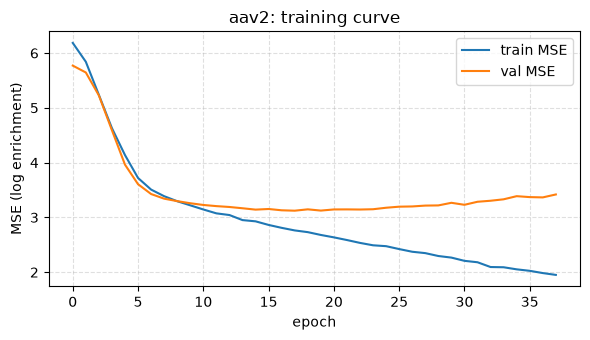

Pearson r (train): 0.8095   (test): 0.4616
weights recovery vs. loaded reference -- F: r=0.9914   J: r=0.9269


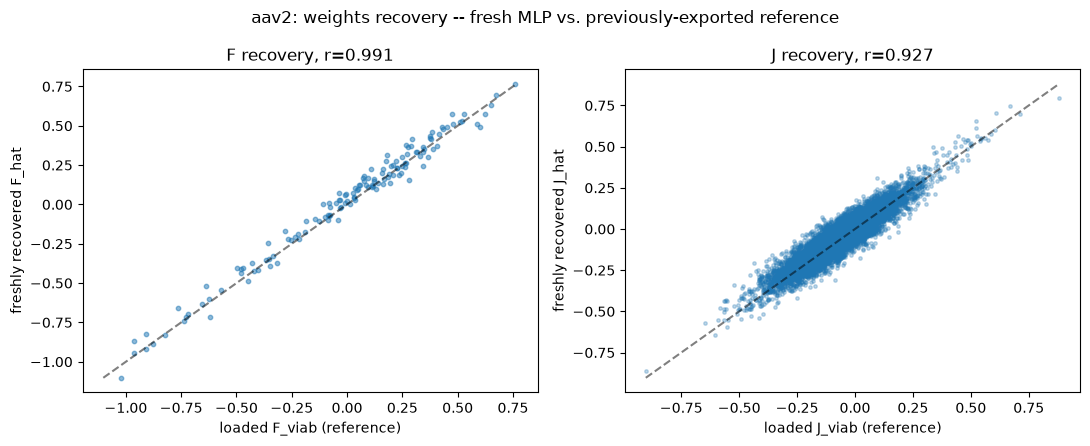

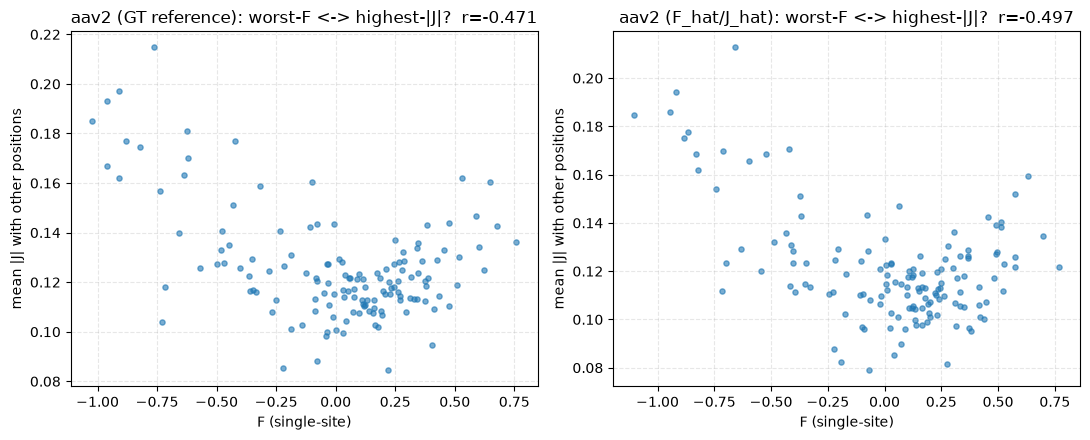

exhaustive scan (landscape + exact F/J): 100%|██████████| 320/320 [03:12<00:00,  1.66it/s]


Exhaustively evaluated ALL 1,280,000,000 possible sequences with this fresh MLP.
predicted log-enrichment range: [-8.16, 5.03]  (histogram range [-8.43, 5.29])   mean over full space (mu) = -1.348
Predicted-log-enrichment percentile of the REAL top-500 variants, vs. the EXHAUSTIVE 1,280,000,000-sequence background:
  median = 85.89th   min = 10.64th   max = 99.90th
  18/500 land in the background's own top 1%   190/500 land in its top 10%


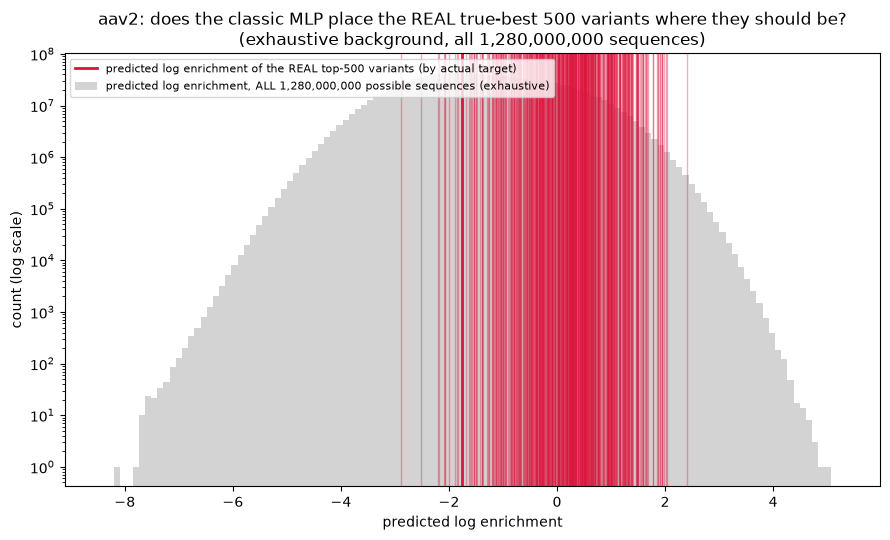


aav2: mutant-scan F_hat/J_hat (M=256 backgrounds) vs. EXACT full-space ANOVA F_exact/J_exact -- F: r=0.9935   J: r=0.9748
  (how much does the small-sample mutant scan differ from the mathematically exact answer?)

aav2 -- rank #1: VKWSSDP   real target (log enrichment)=6.434   MLP predicted log enrichment=-1.752


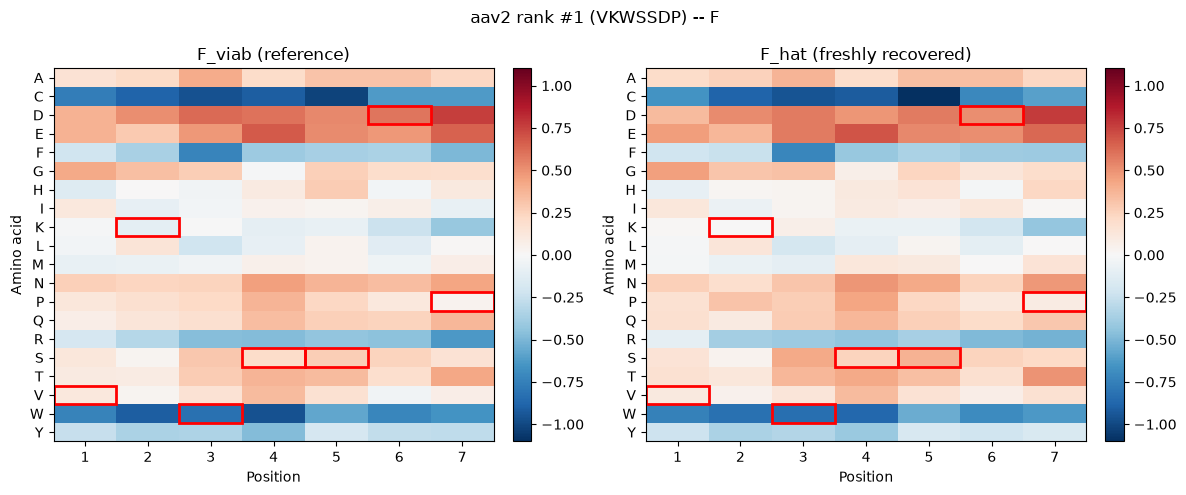

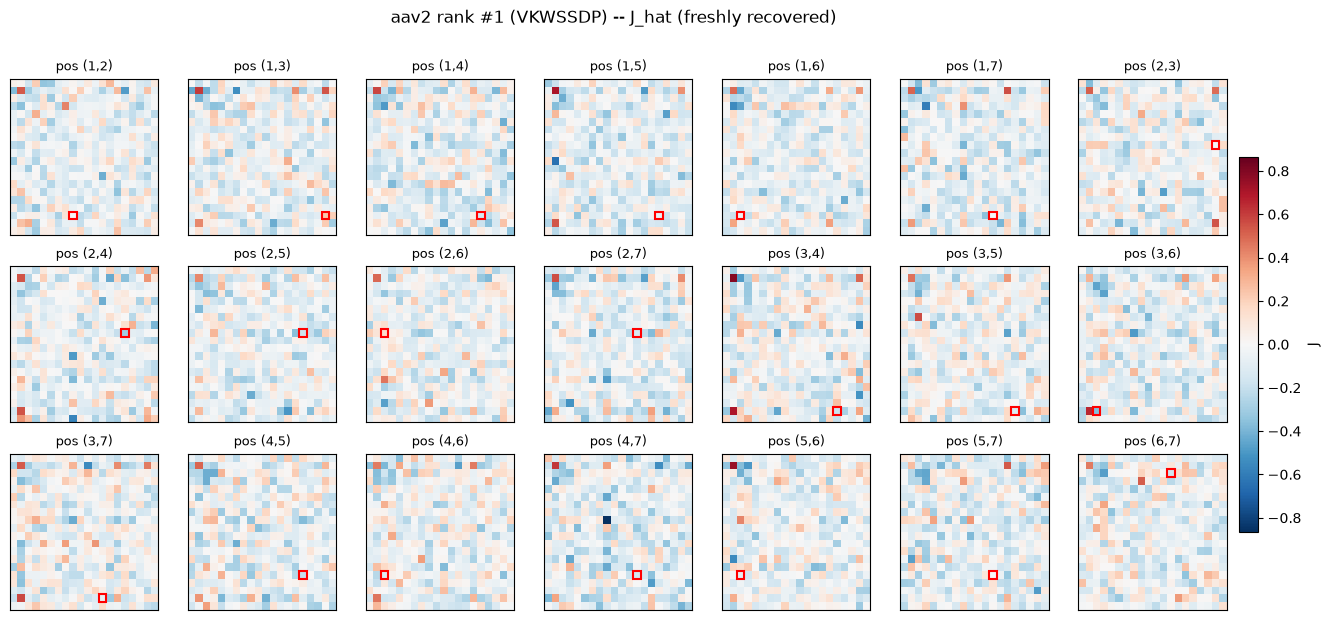


aav2 -- rank #2: HNAIKIE   real target (log enrichment)=6.407   MLP predicted log enrichment=1.628


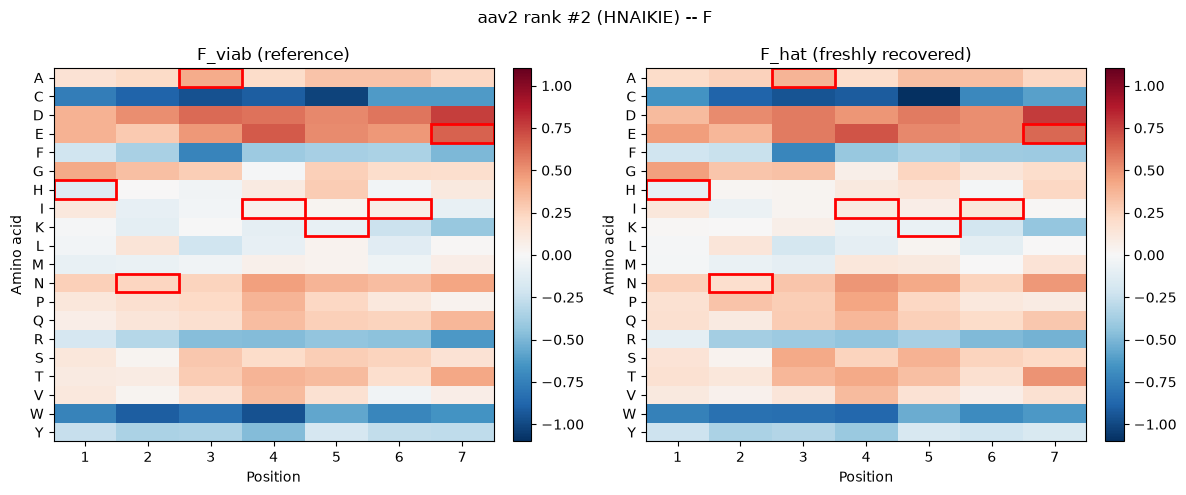

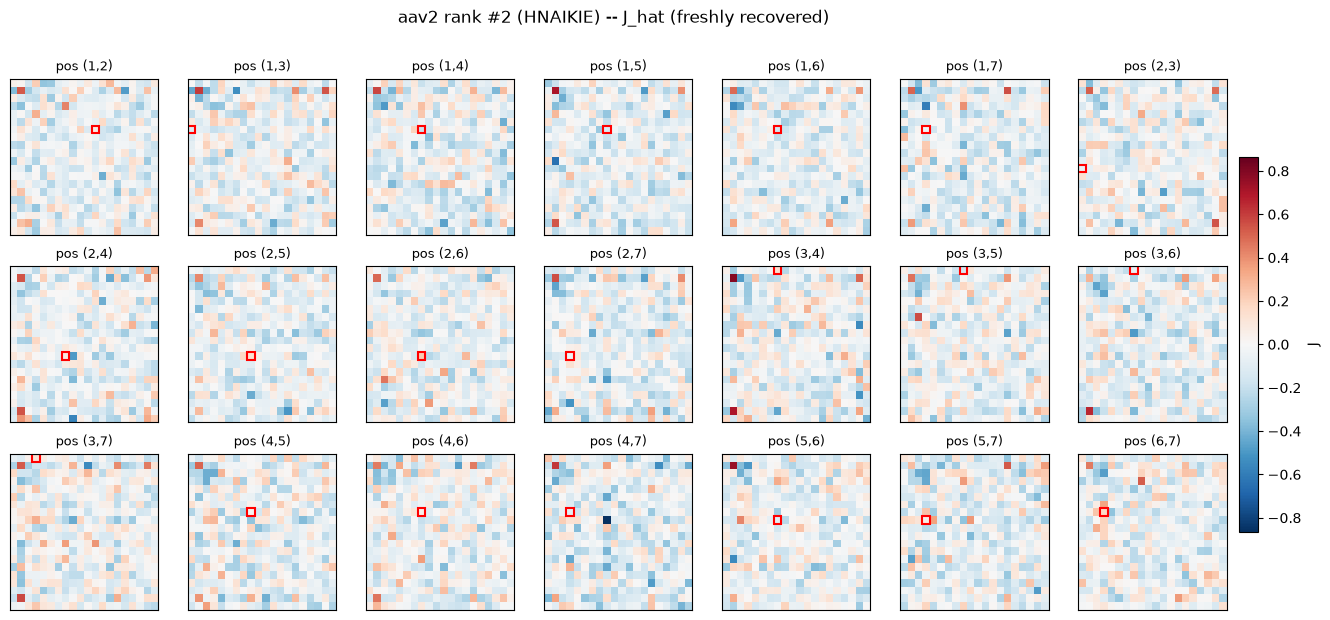


aav2 -- rank #3: DLVSLPH   real target (log enrichment)=6.047   MLP predicted log enrichment=1.300


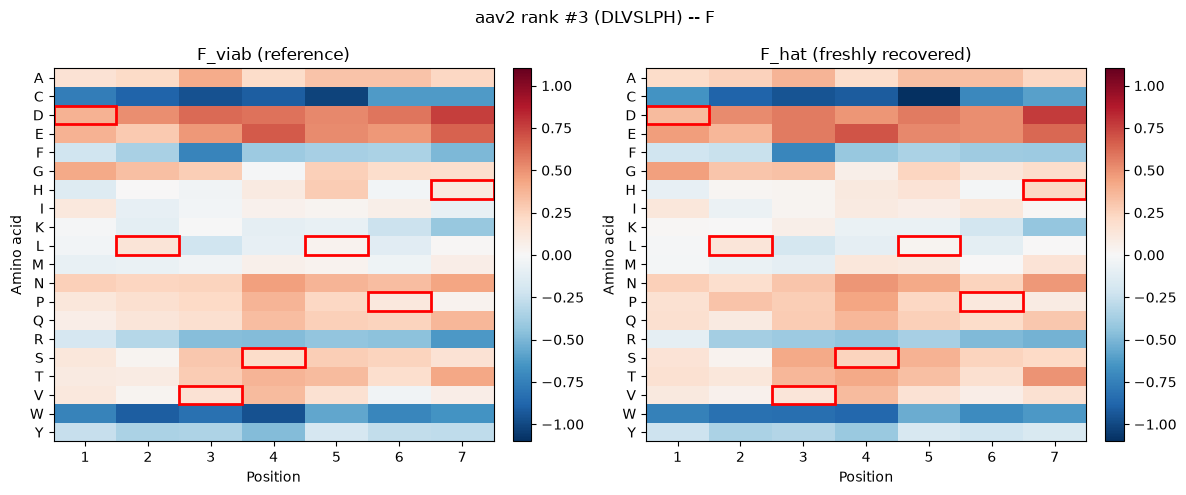

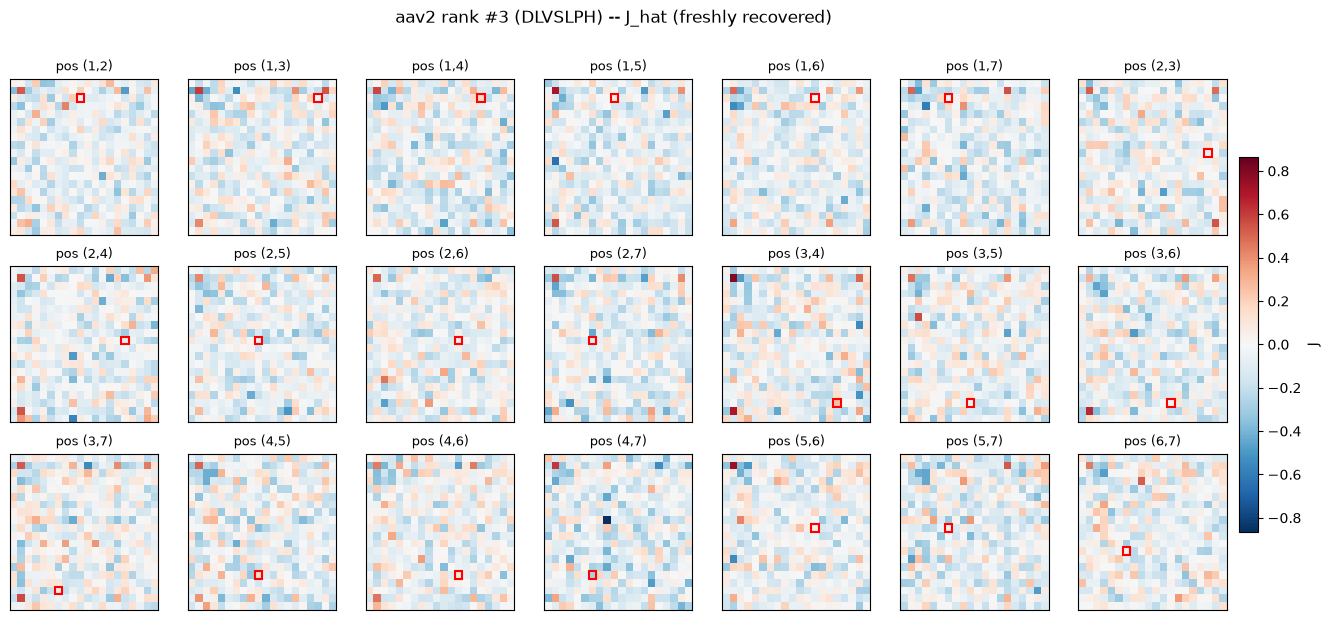


aav2 -- rank #4: PSSQPQM   real target (log enrichment)=5.498   MLP predicted log enrichment=-0.455


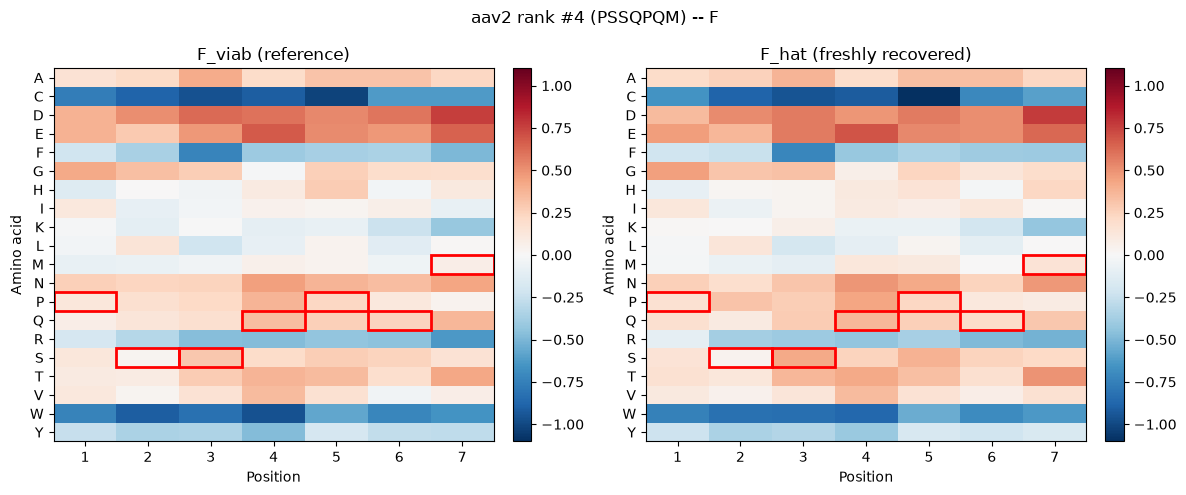

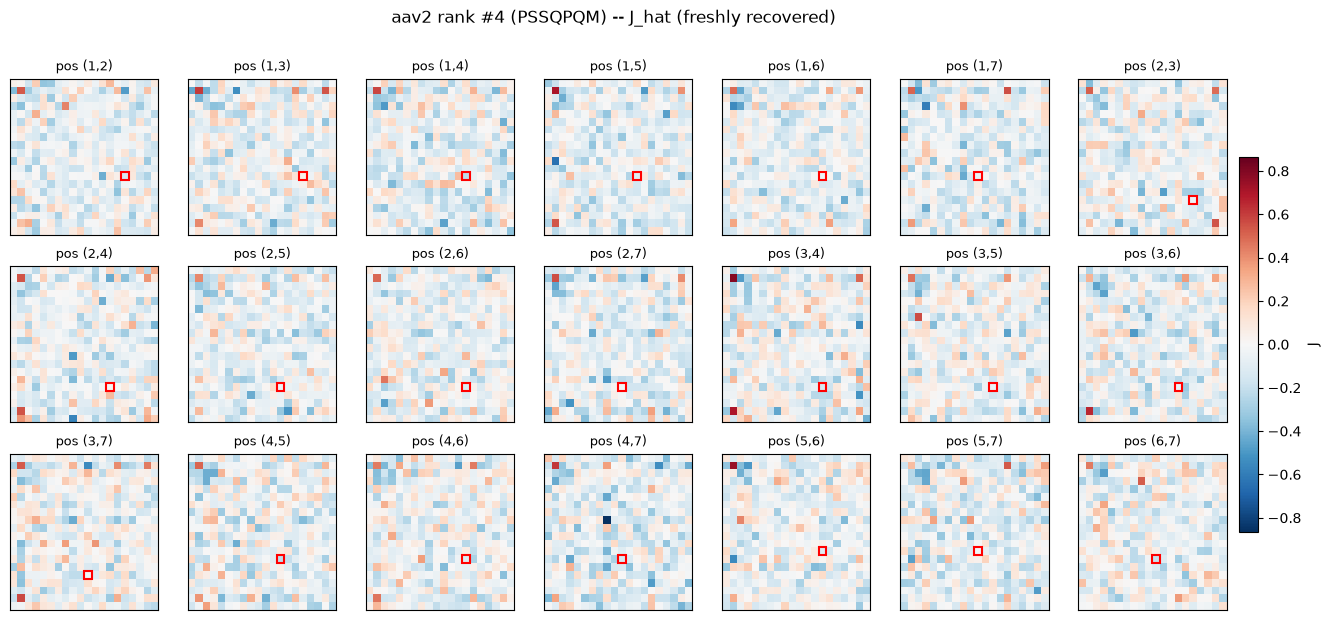


aav2 -- rank #5: KTNGDSL   real target (log enrichment)=5.414   MLP predicted log enrichment=-0.001


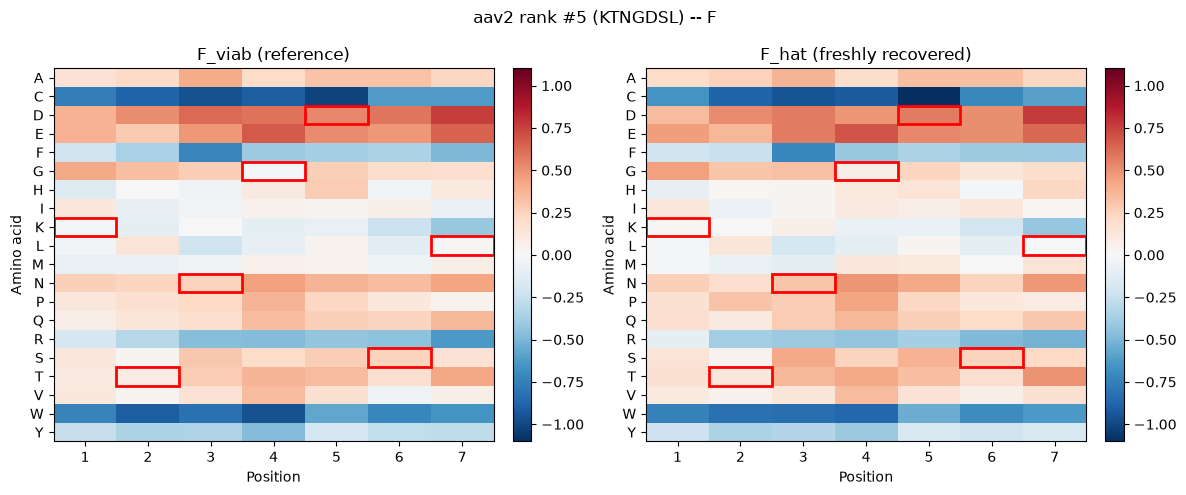

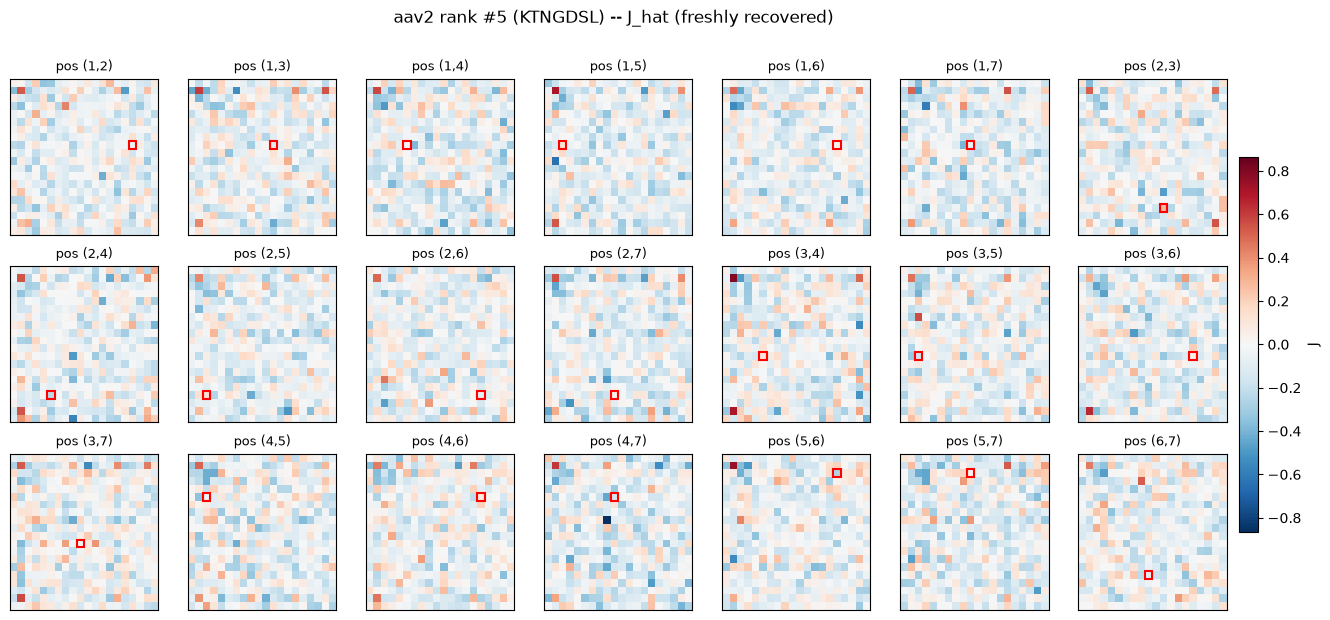


aav2: top-500 real variants -- GT_F/GT_J/hat_F/hat_J/exact_F/exact_J summary (mean |.| -- is J small relative to F for the BEST sequences?)
  mean|GT_F|    = 1.034    mean|GT_J|    = 1.016
  mean|F_hat|   = 1.212    mean|J_hat|   = 0.796
  mean|F_exact| = 1.010    mean|J_exact| = 0.564
  within top-500: corr(real_target, exact_total) = 0.016   corr(real_target, predicted_log_enrichment) = -0.012
  sequence  real_target  predicted_log_enrichment      GT_F      GT_J  GT_total     F_hat     J_hat  hat_total   F_exact   J_exact  exact_total
0  VKWSSDP     6.433817                 -1.751723  0.282837 -2.291104 -2.008267  0.510747 -1.929815  -1.419069  0.441499 -0.995341    -0.553843
1  HNAIKIE     6.407465                  1.627756  1.175589 -0.581677  0.593911  1.243810 -0.046760   1.197049  1.058741  1.033687     2.092427
2  DLVSLPH     6.046794                  1.300388  1.154363 -0.295675  0.858688  1.240861  0.013753   1.254614  1.094919  1.114407     2.209326
3  PSSQPQM     5.497663 

In [7]:
result_aav2, variant_df_aav2, F_ref_aav2, J_ref_aav2, F_exact_aav2, J_exact_aav2 = run_dataset("aav2")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same population/criteria as the aav2 section above: the REAL aav5.csv sequences restricted to the HELD-OUT test split (<code>idx_test</code>), ranked by real <code>target</code>. <code>GT_F</code>/<code>GT_J</code> = loaded reference weights, <code>F_hat</code>/<code>J_hat</code> = sampled mutant-scan of this run's fresh MLP, <code>F_exact</code>/<code>J_exact</code> = that same MLP's exact full-20^7-space decomposition.
</div>

### aav5


aav5
737,587 variants -- train: 313,475  val: 55,318  test: 368,794


Training ProfileMLP:  11%|█         | 32/300 [00:06<00:51,  5.24it/s]


Early stopping at epoch 32 (best val MSE=7.1908)


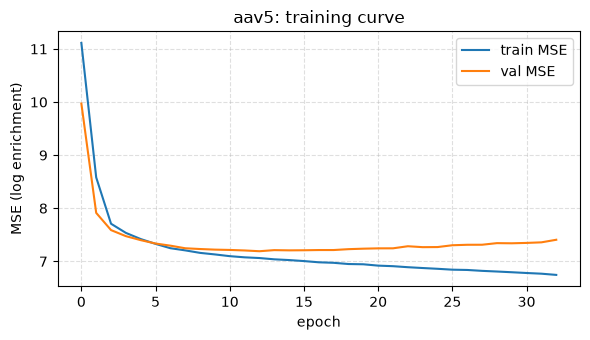

Pearson r (train): 0.4882   (test): 0.3856
weights recovery vs. loaded reference -- F: r=0.9966   J: r=0.9048


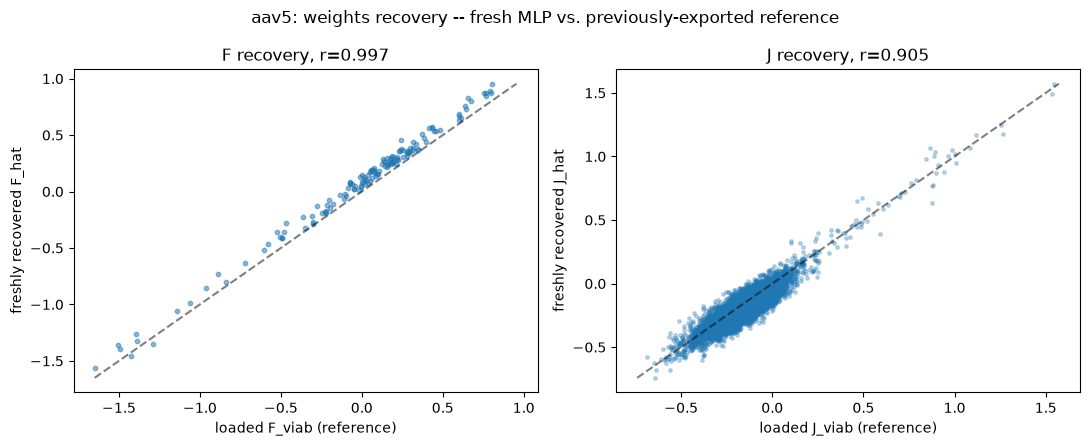

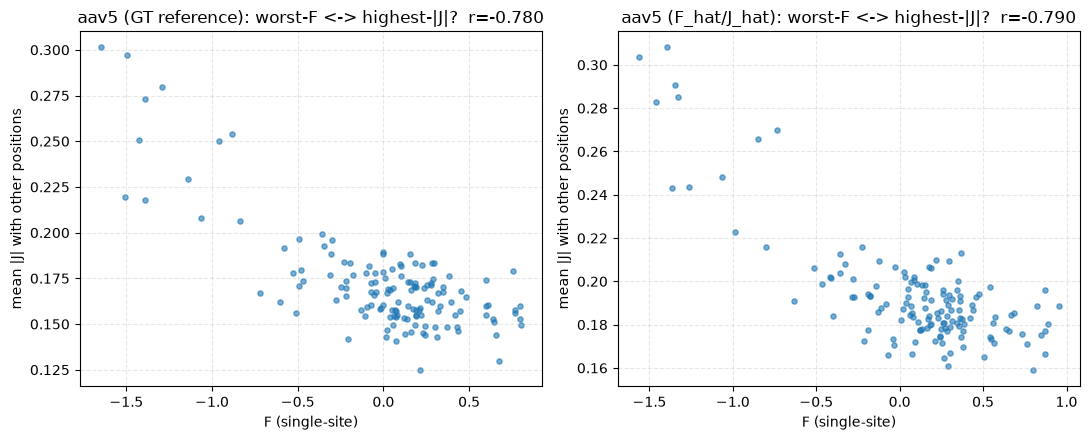

exhaustive scan (landscape + exact F/J): 100%|██████████| 320/320 [03:16<00:00,  1.63it/s]


Exhaustively evaluated ALL 1,280,000,000 possible sequences with this fresh MLP.
predicted log-enrichment range: [-9.29, 3.04]  (histogram range [-9.53, 3.29])   mean over full space (mu) = -2.142
Predicted-log-enrichment percentile of the REAL top-500 variants, vs. the EXHAUSTIVE 1,280,000,000-sequence background:
  median = 88.95th   min = 4.14th   max = 99.96th
  31/500 land in the background's own top 1%   238/500 land in its top 10%


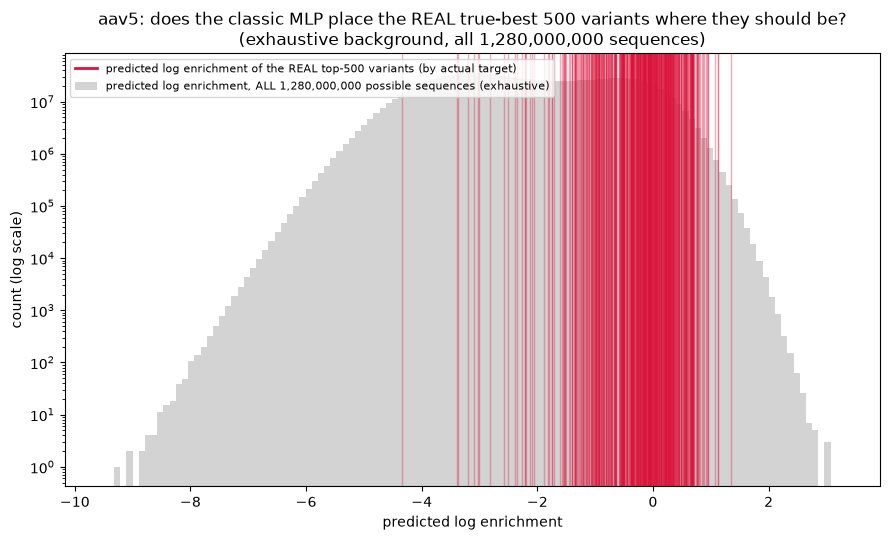


aav5: mutant-scan F_hat/J_hat (M=256 backgrounds) vs. EXACT full-space ANOVA F_exact/J_exact -- F: r=0.9879   J: r=0.9429
  (how much does the small-sample mutant scan differ from the mathematically exact answer?)

aav5 -- rank #1: IKGGQEV   real target (log enrichment)=8.225   MLP predicted log enrichment=0.682


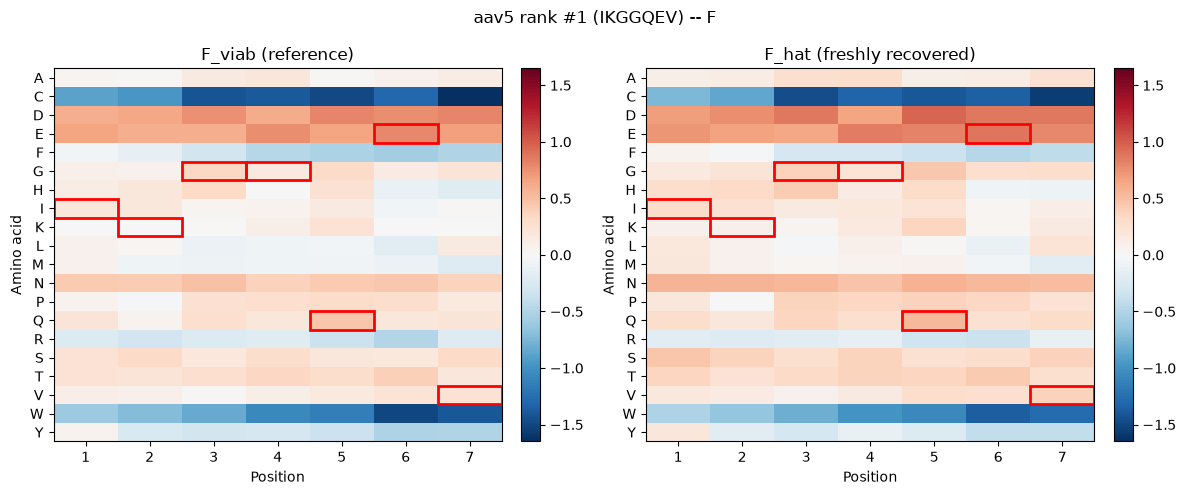

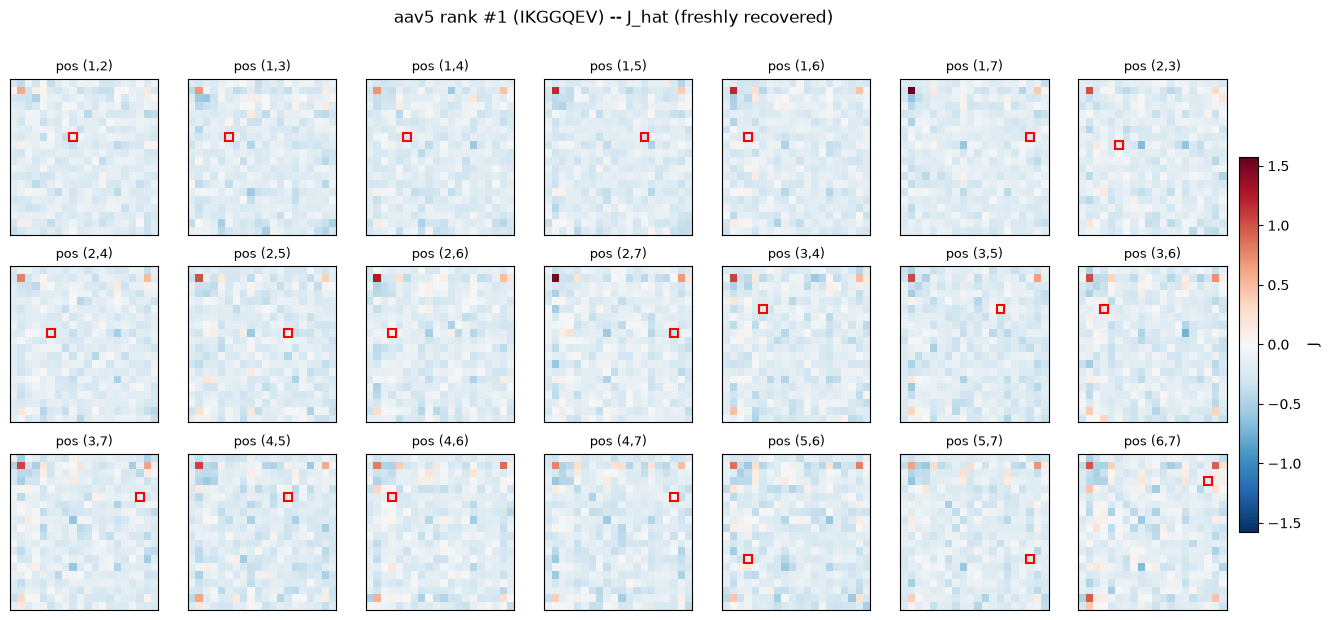


aav5 -- rank #2: KDNSLMS   real target (log enrichment)=8.146   MLP predicted log enrichment=0.399


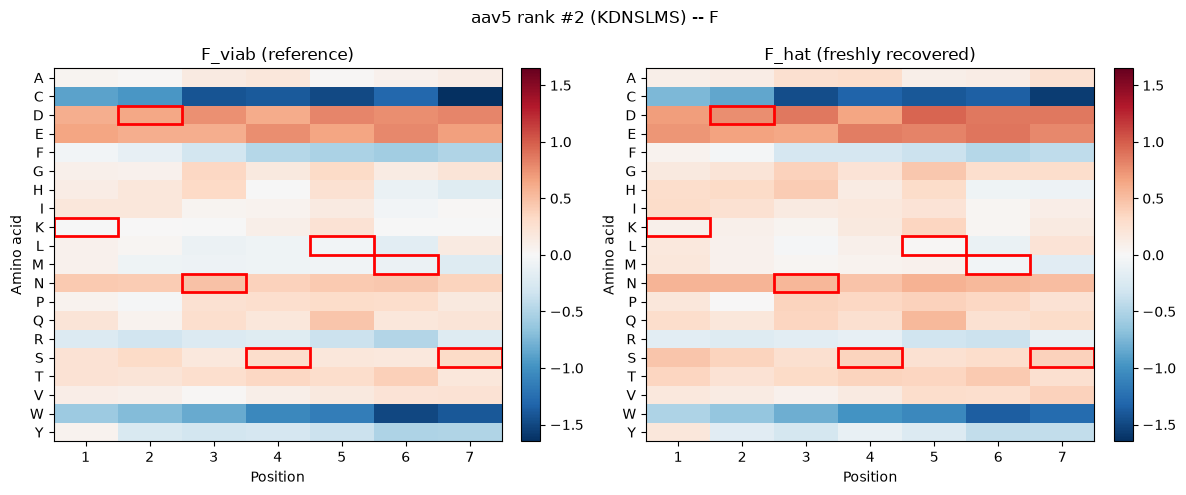

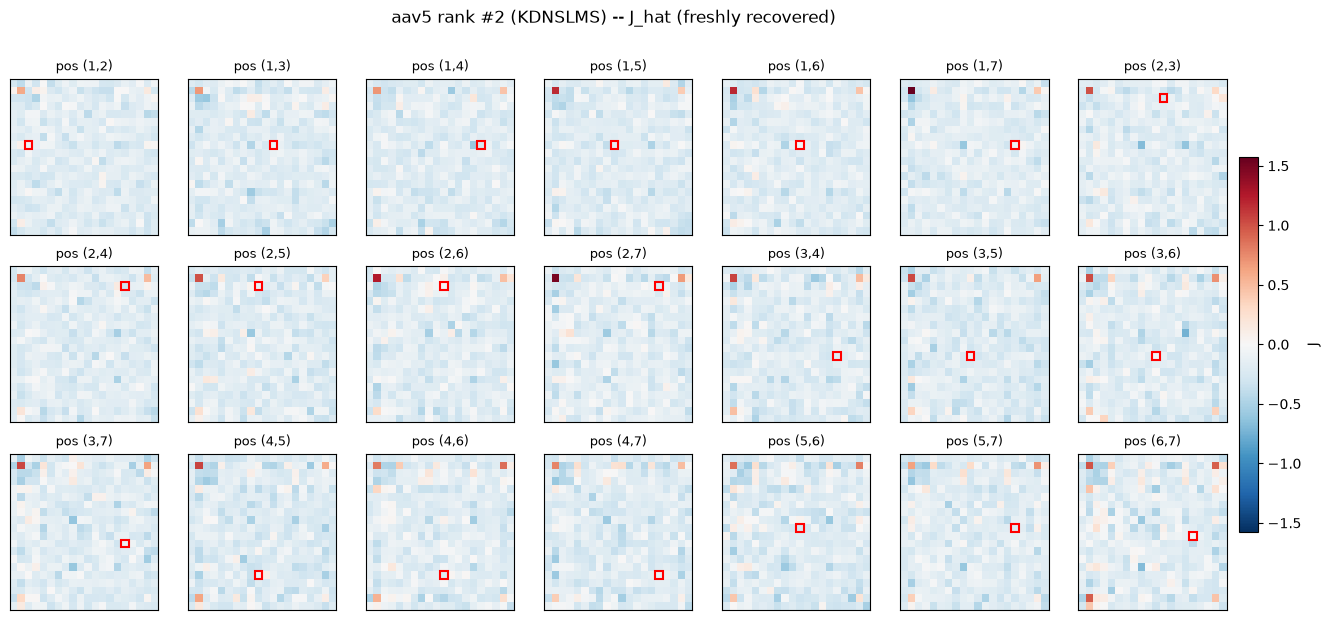


aav5 -- rank #3: SHSNSVD   real target (log enrichment)=7.996   MLP predicted log enrichment=0.880


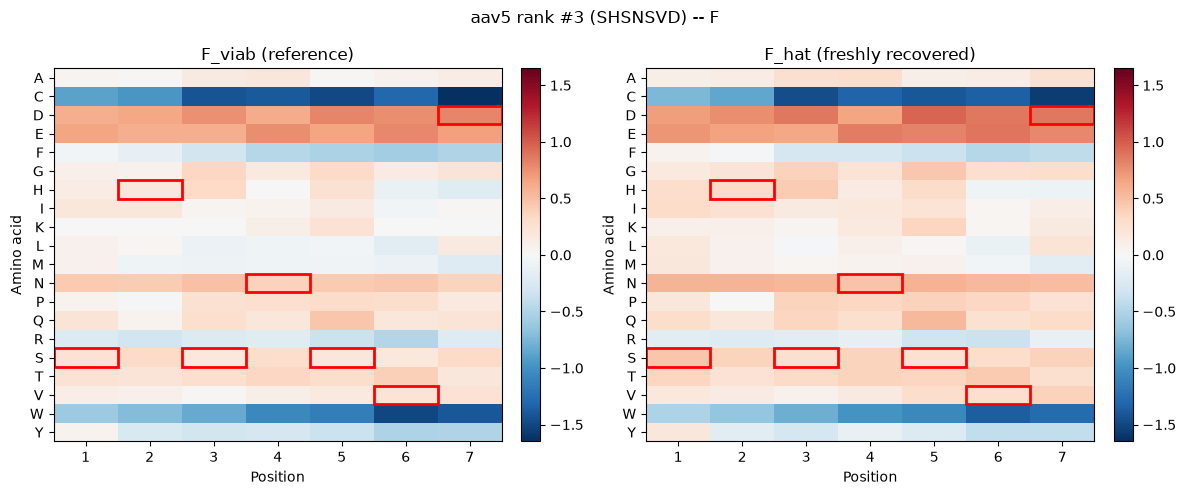

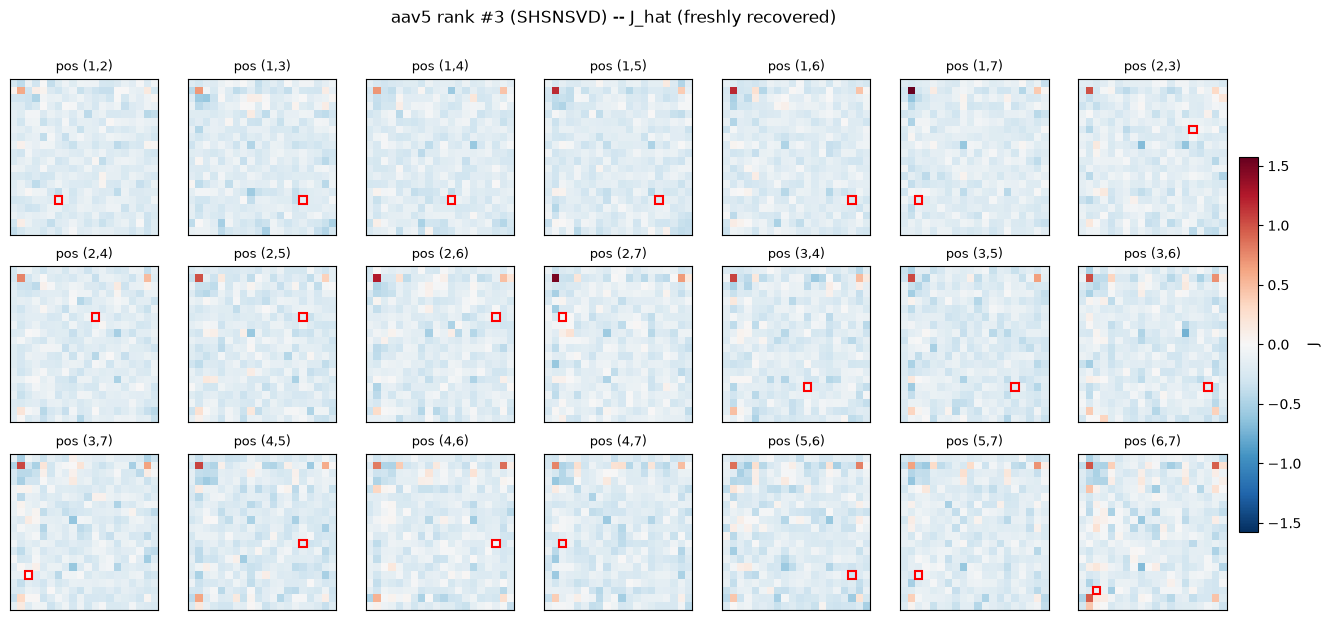


aav5 -- rank #4: SIGNHVD   real target (log enrichment)=7.620   MLP predicted log enrichment=0.951


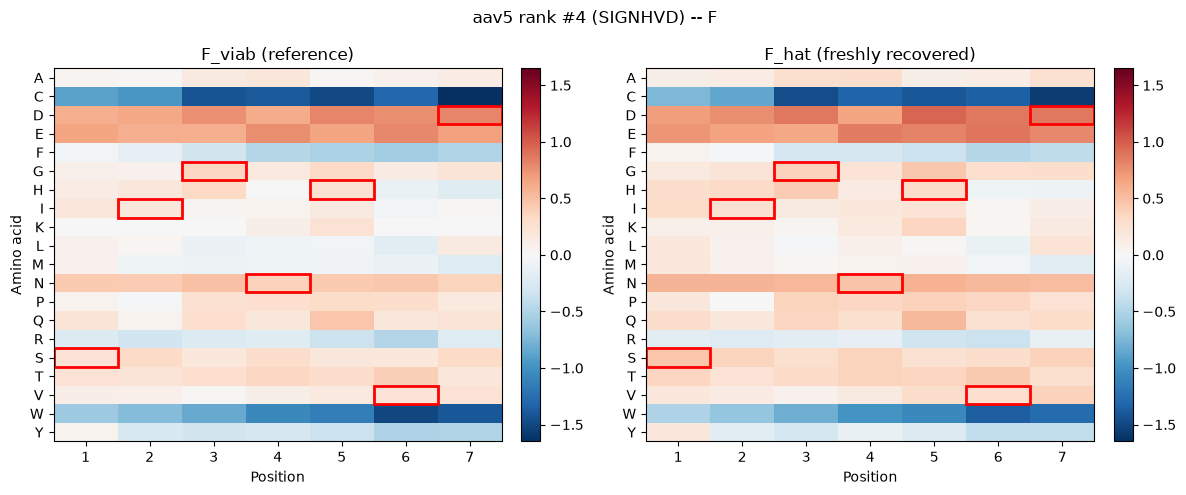

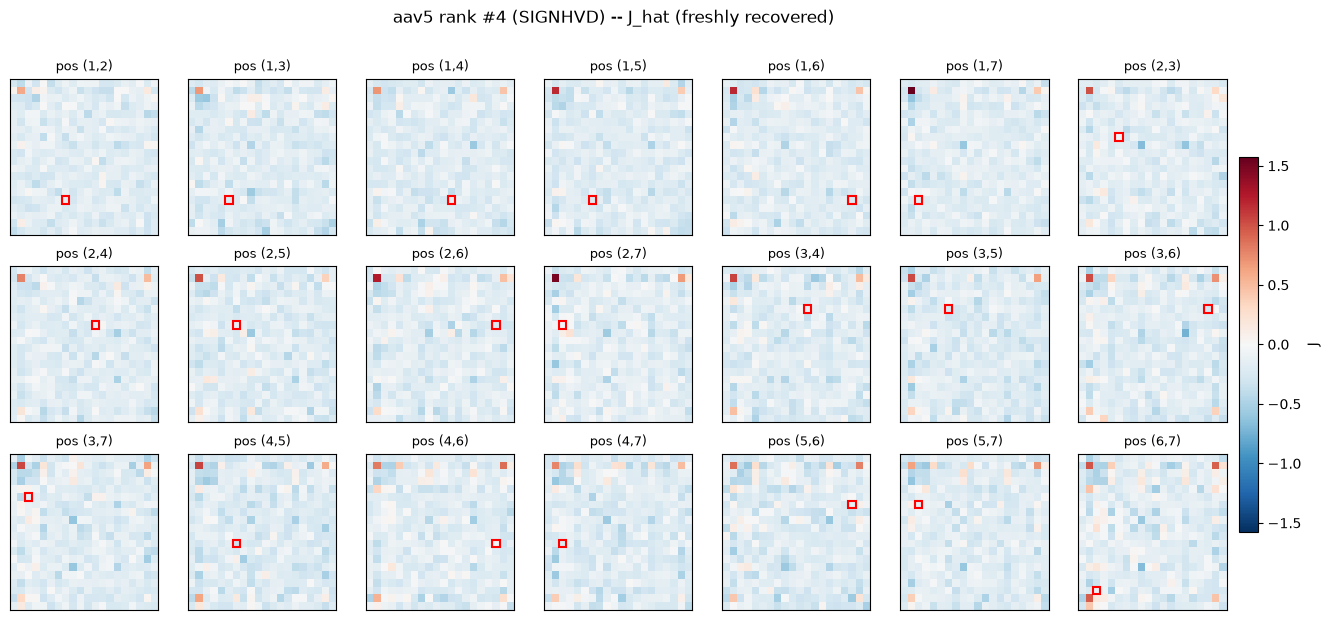


aav5 -- rank #5: LDDKARM   real target (log enrichment)=7.607   MLP predicted log enrichment=0.146


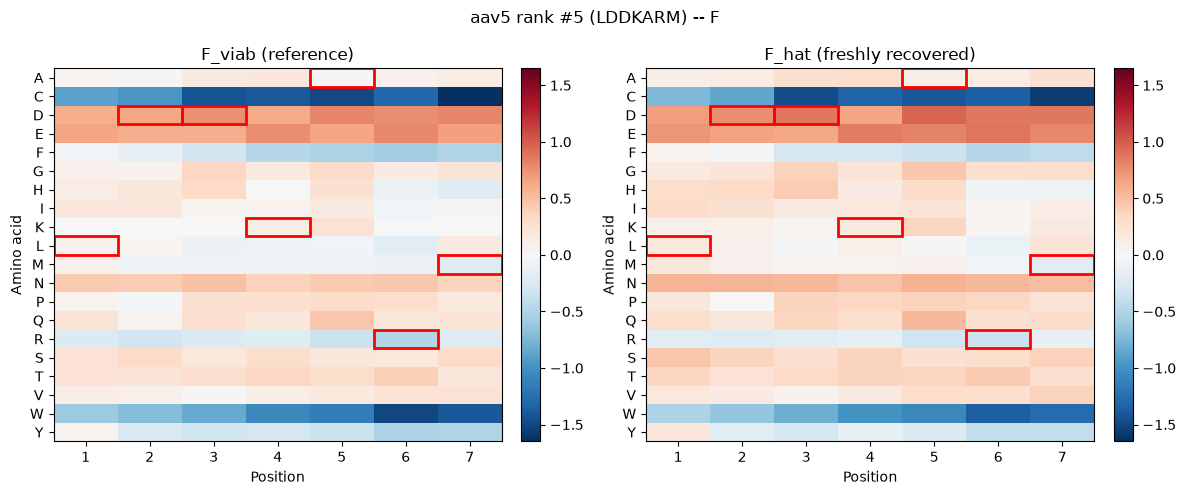

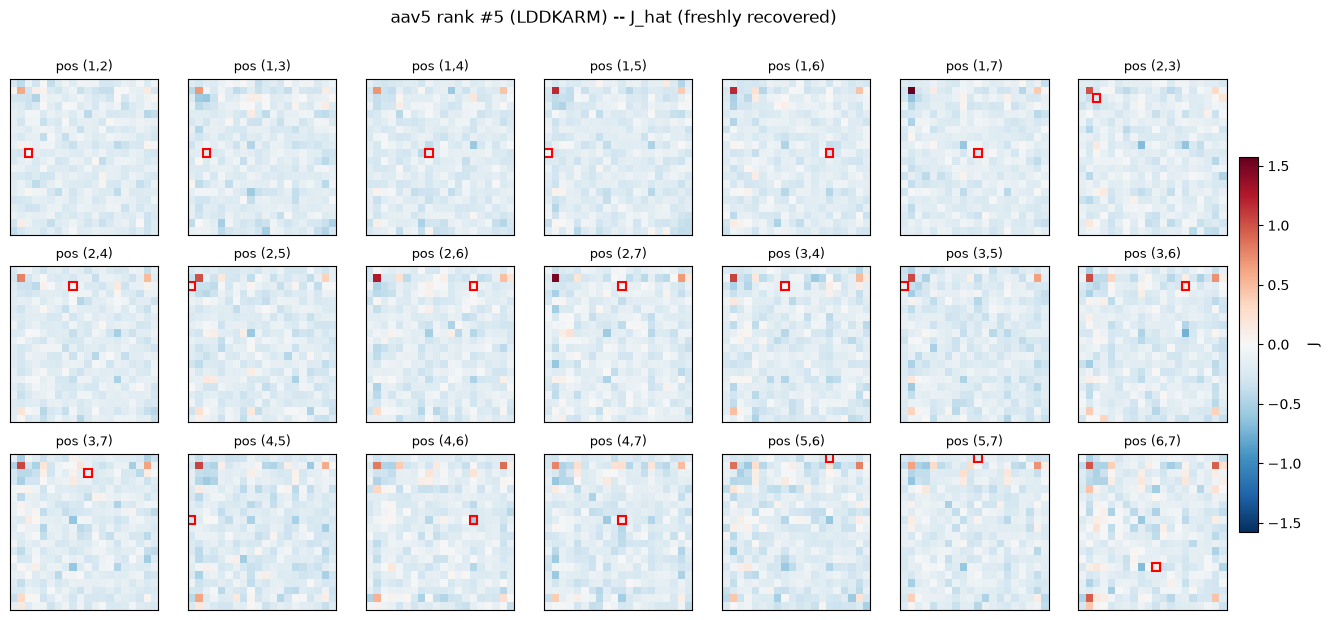


aav5: top-500 real variants -- GT_F/GT_J/hat_F/hat_J/exact_F/exact_J summary (mean |.| -- is J small relative to F for the BEST sequences?)
  mean|GT_F|    = 1.596    mean|GT_J|    = 3.039
  mean|F_hat|   = 2.214    mean|J_hat|   = 3.524
  mean|F_exact| = 1.509    mean|J_exact| = 0.451
  within top-500: corr(real_target, exact_total) = -0.095   corr(real_target, predicted_log_enrichment) = -0.079
  sequence  real_target  predicted_log_enrichment      GT_F      GT_J  GT_total     F_hat     J_hat  hat_total   F_exact   J_exact  exact_total
0  IKGGQEV     8.225389                  0.682251  2.201766 -3.068478 -0.866712  2.807767 -3.723801  -0.916034  2.082390  0.138546     2.220935
1  KDNSLMS     8.146339                  0.399163  1.583248 -2.990941 -1.407692  2.117038 -3.027103  -0.910065  1.470776  0.544707     2.015483
2  SHSNSVD     7.995557                  0.880002  2.200803 -2.495244 -0.294441  2.907689 -3.304435  -0.396746  2.071117  0.861780     2.932897
3  SIGNHVD     7.620281

In [8]:
result_aav5, variant_df_aav5, F_ref_aav5, J_ref_aav5, F_exact_aav5, J_exact_aav5 = run_dataset("aav5")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same population/criteria as the aav2 section above: the REAL aav9.csv sequences restricted to the HELD-OUT test split (<code>idx_test</code>, 34,388 of the 68,776 rows), ranked by real <code>target</code>. This is the table with <code>mean|GT_F|=4.215 &gt;&gt; mean|GT_J|=1.332</code> etc. -- <code>GT_F</code>/<code>GT_J</code> = loaded reference weights, <code>F_hat</code>/<code>J_hat</code> = sampled mutant-scan of this run's fresh MLP, <code>F_exact</code>/<code>J_exact</code> = that same MLP's exact full-20^7-space decomposition. None of these 500 sequences come from a brute-force search of the full combinatorial space.
</div>

### aav9


aav9
68,776 variants -- train: 29,230  val: 5,158  test: 34,388


Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]

Training ProfileMLP:  20%|█▉        | 59/300 [00:04<00:16, 14.57it/s]


Early stopping at epoch 59 (best val MSE=2.9935)


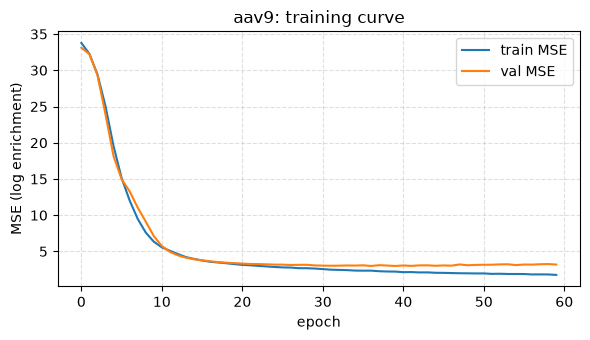

Pearson r (train): 0.9667   (test): 0.9133
weights recovery vs. loaded reference -- F: r=0.9926   J: r=0.7978


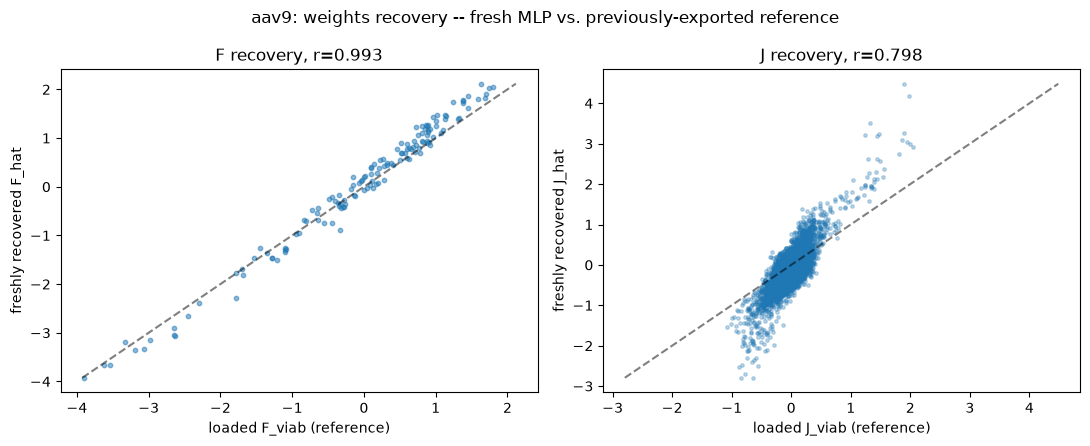

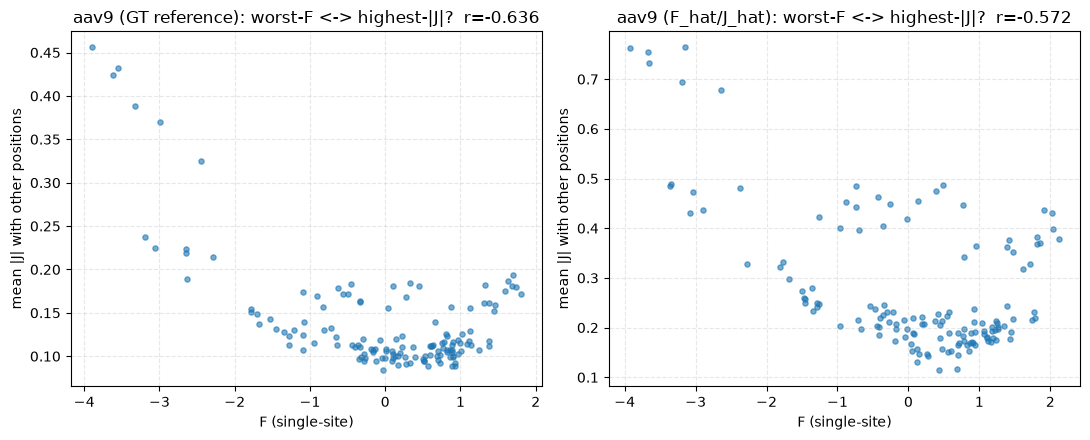

exhaustive scan (landscape + exact F/J): 100%|██████████| 320/320 [03:11<00:00,  1.67it/s]


Exhaustively evaluated ALL 1,280,000,000 possible sequences with this fresh MLP.
predicted log-enrichment range: [-19.42, 6.76]  (histogram range [-19.95, 7.28])   mean over full space (mu) = -4.221
Predicted-log-enrichment percentile of the REAL top-500 variants, vs. the EXHAUSTIVE 1,280,000,000-sequence background:
  median = 94.27th   min = 51.81th   max = 100.00th
  63/500 land in the background's own top 1%   355/500 land in its top 10%


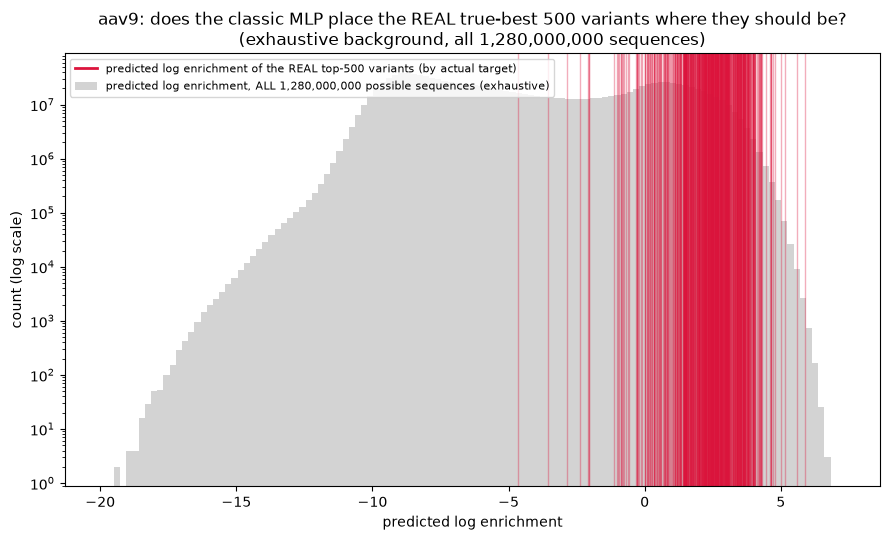


aav9: mutant-scan F_hat/J_hat (M=256 backgrounds) vs. EXACT full-space ANOVA F_exact/J_exact -- F: r=0.9960   J: r=0.9782
  (how much does the small-sample mutant scan differ from the mathematically exact answer?)

aav9 -- rank #1: VAVRQQG   real target (log enrichment)=7.473   MLP predicted log enrichment=1.471


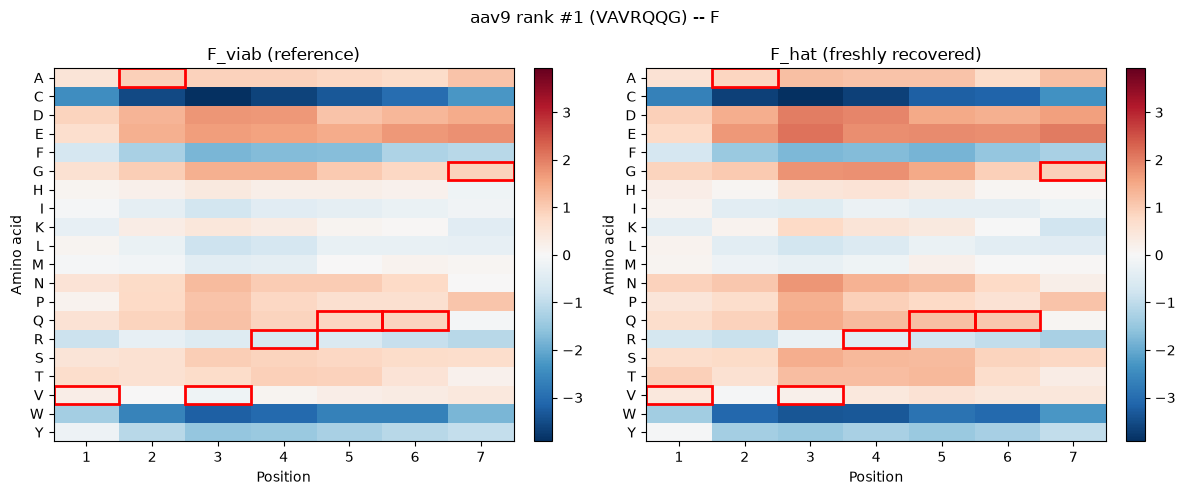

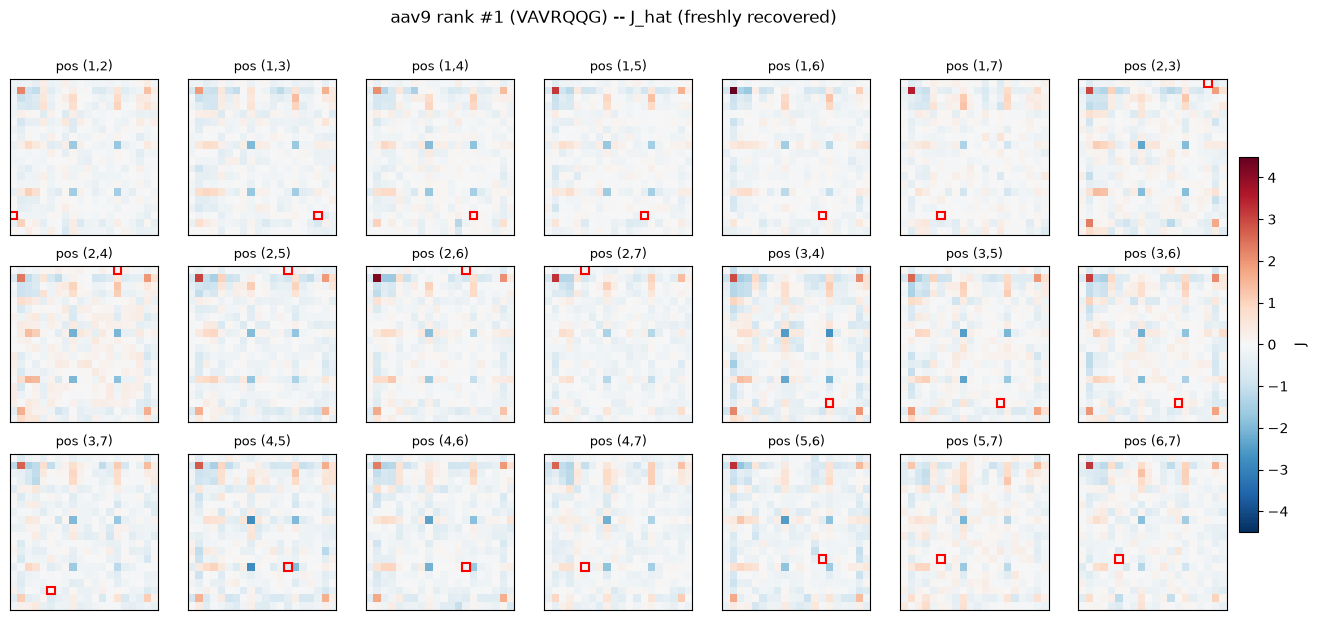


aav9 -- rank #2: PPPVASV   real target (log enrichment)=7.473   MLP predicted log enrichment=1.977


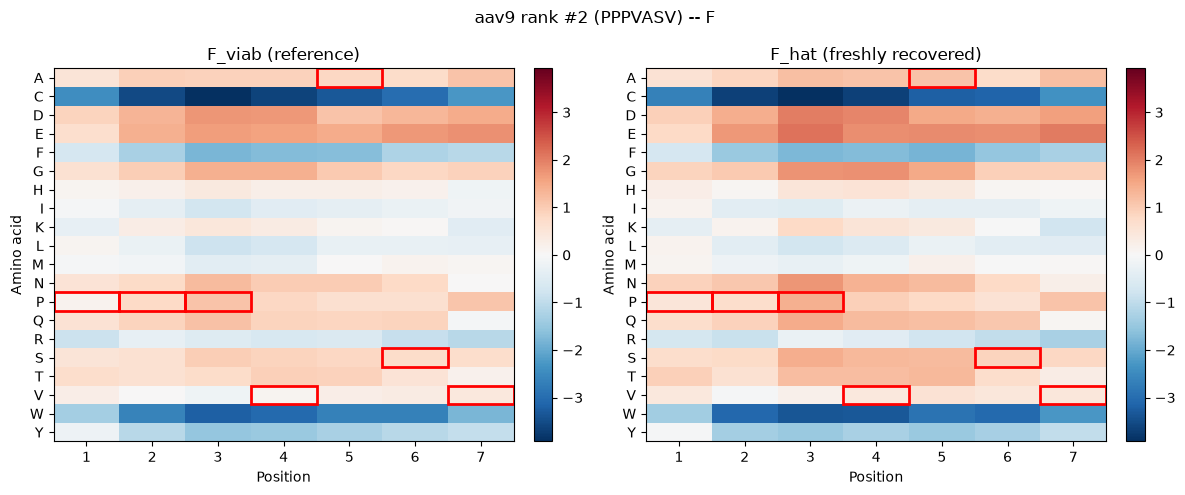

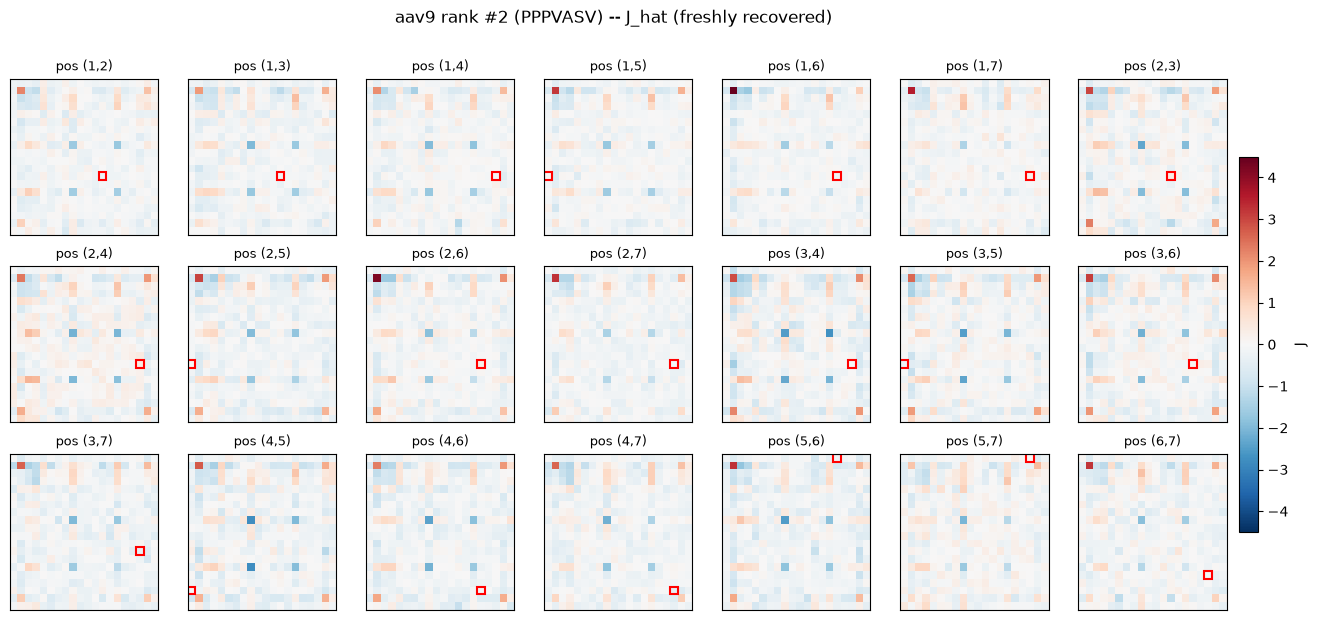


aav9 -- rank #3: LPPRNAA   real target (log enrichment)=7.473   MLP predicted log enrichment=3.781


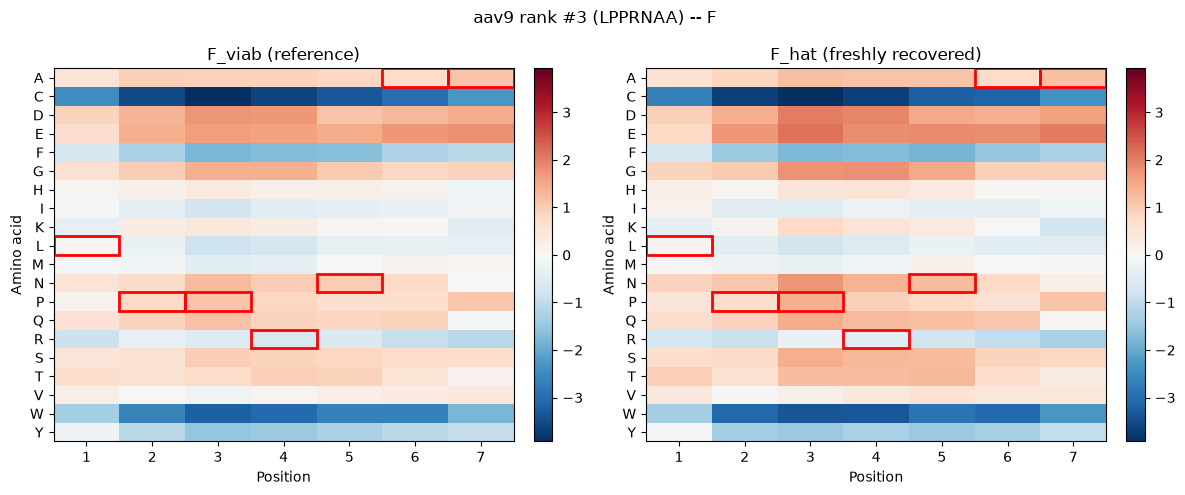

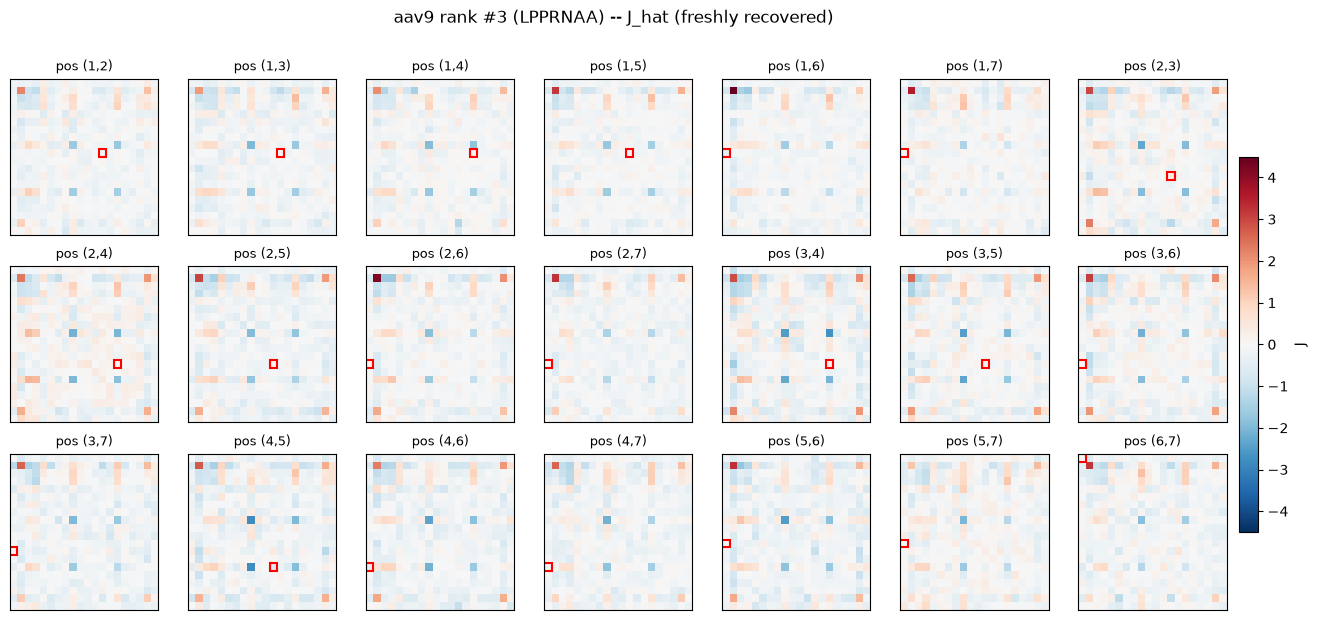


aav9 -- rank #4: NAHPALG   real target (log enrichment)=7.473   MLP predicted log enrichment=3.674


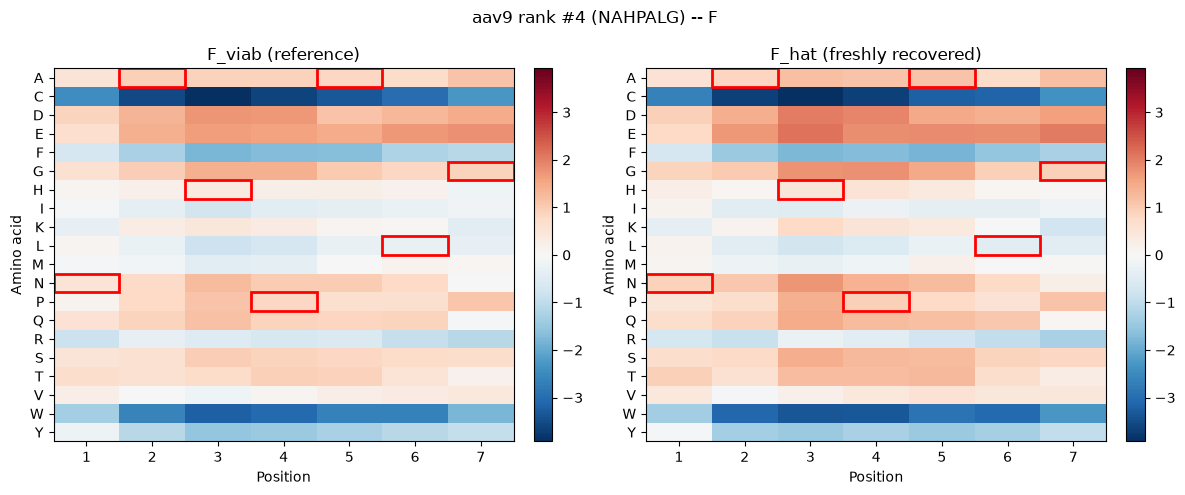

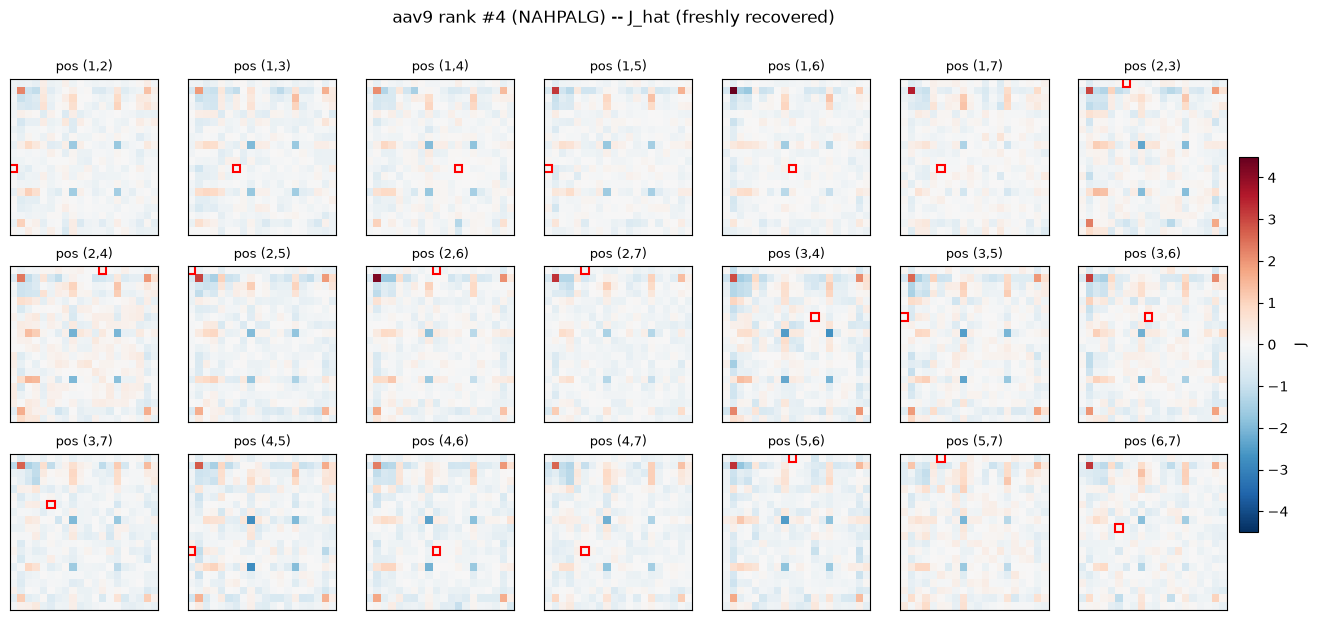


aav9 -- rank #5: AQPTQQL   real target (log enrichment)=7.473   MLP predicted log enrichment=2.468


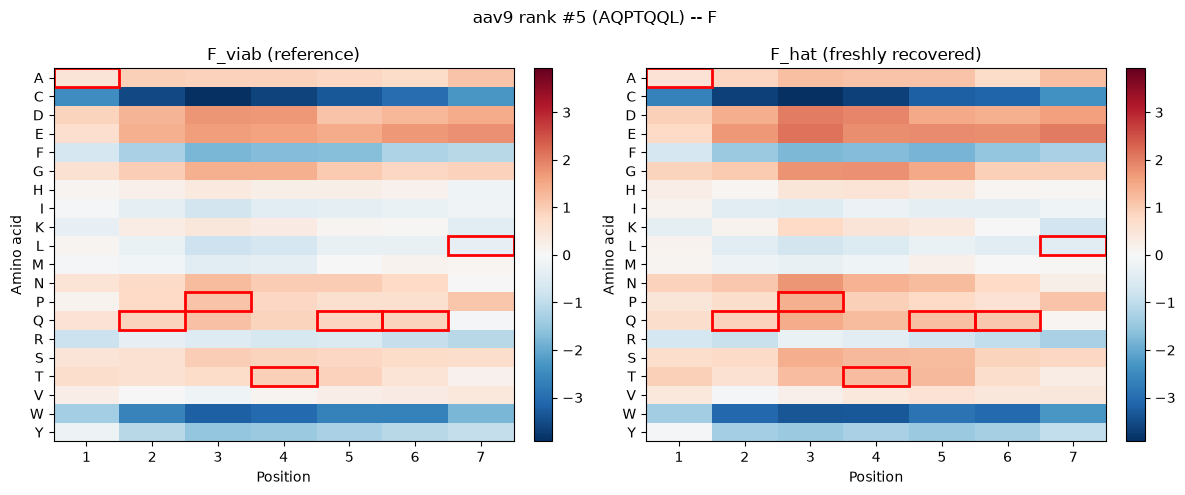

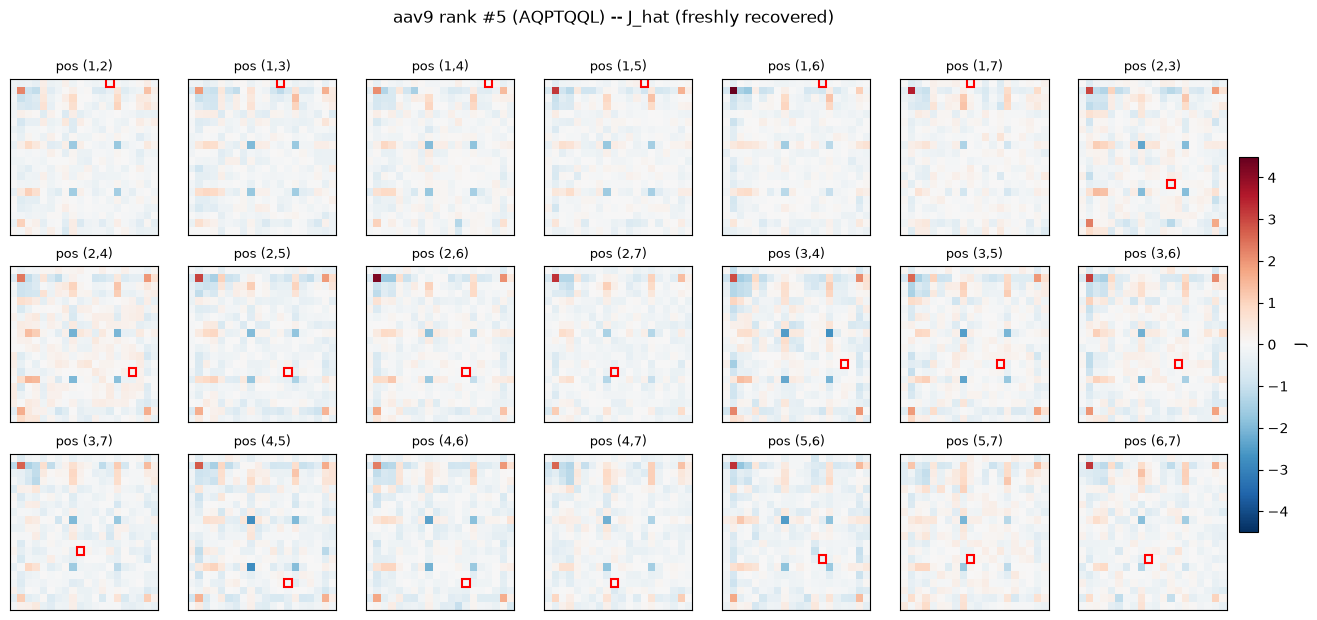


aav9: top-500 real variants -- GT_F/GT_J/hat_F/hat_J/exact_F/exact_J summary (mean |.| -- is J small relative to F for the BEST sequences?)
  mean|GT_F|    = 3.448    mean|GT_J|    = 0.815
  mean|F_hat|   = 4.474    mean|J_hat|   = 0.985
  mean|F_exact| = 3.960    mean|J_exact| = 1.574
  within top-500: corr(real_target, exact_total) = 0.023   corr(real_target, predicted_log_enrichment) = -0.016
  sequence  real_target  predicted_log_enrichment      GT_F      GT_J  GT_total     F_hat     J_hat  hat_total   F_exact   J_exact  exact_total
0  VAVRQQG     7.472986                  1.471110  3.057043  0.506745  3.563788  4.201832 -1.245731   2.956101  3.528269  1.265240     4.793509
1  PPPVASV     7.472986                  1.977379  4.084858  0.947744  5.032602  5.399156 -0.689748   4.709407  4.787700  1.821007     6.608707
2  LPPRNAA     7.472986                  3.781116  4.205602  1.490927  5.696529  4.920290 -0.838440   4.081850  4.375747  1.773247     6.148994
3  NAHPALG     7.472986 

In [9]:
result_aav9, variant_df_aav9, F_ref_aav9, J_ref_aav9, F_exact_aav9, J_exact_aav9 = run_dataset("aav9")


## Summary across the three datasets


In [10]:
summary = pd.DataFrame([result_aav2, result_aav5, result_aav9]).set_index("name")
summary


,r_train,r_test,r_F,r_J,r_FJ_ref,r_FJ_hat,r_F_exact,r_J_exact,pct_median,pct_min,top1pct,top10pct
name,,,,,,,,,,,,
aav2,0.809489,0.461610,0.991357,0.926878,-0.471154,-0.497262,0.993455,0.974771,85.888945,10.641520,18,190
aav5,0.488219,0.385587,0.996564,0.904800,-0.780332,-0.790160,0.987865,0.942877,88.952449,4.142782,31,238
aav9,0.966650,0.913345,0.992566,0.797781,-0.635892,-0.571584,0.995974,0.978203,94.272598,51.814485,63,355


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
This section's two top-500 sets are GLOBAL/THEORETICAL, found by exhaustively scanning ALL 20^7 &asymp; 1.28 billion possible sequences (<code>cross_matrix_scan</code>/<code>score_FJ</code>, closed-form, no neural net) -- neither set was ever synthesized or measured. "MLP-best-500" = top-500 by that dataset's fresh MLP's exact <code>F_exact</code>/<code>J_exact</code>; "TRUE-best-500" = top-500 by the loaded reference <code>F_viab</code>/<code>J_viab</code>. Each set is then re-scored under the OTHER matrix. Do not confuse either of these with the REAL held-out top-500 from the aav2/aav5/aav9 sections above (real measured sequences, <code>idx_test</code> only) -- these two populations are entirely different objects that happen to share the name "top-500".
</div>

## Cross-matrix check: do the best variants according to one weight matrix look good under the other?

The central question for this whole project is **how to recover the best variants** -- so
the real test isn't "does the MLP fit `target` well" in the abstract, it's "if you searched
using what the MLP learned, would you actually find good capsids?" This checks that directly,
in both directions, using the closed-form `F`/`J` matrices (fast to search exhaustively --
no neural net needed):

- **MLP-best under the TRUE distribution**: exhaustively find the top-500 sequences according
  to the MLP's own (exact, noise-free) `F_exact`/`J_exact`, then score THOSE sequences with the
  TRUE reference `F_viab`/`J_viab`, and see where they land in the TRUE score's full-space
  distribution. If the MLP's own favorites score badly under the true weights, searching with
  the MLP would waste resources on bad candidates.
- **TRUE-best under the MLP's distribution**: the reverse -- exhaustively find the top-500
  sequences according to the TRUE `F_viab`/`J_viab`, score them with the MLP's `F_exact`/
  `J_exact`, and see where they land in the MLP score's full-space distribution. If the MLP
  doesn't recognize the genuinely best variants as good, it would never surface them.

Both scores here are the closed-form additive+pairwise reconstruction (`F` + `J`), not
`predicted_log_enrichment` -- matching `Protocol.compute_score`'s convention elsewhere in the
project.


In [11]:
@jax.jit
def _rawidx_chunk(idx, L=num_positions, A=num_amino_acids):
    """Decode a linear index in [0, A**L) into its base-A digit sequence (raw indices, no
    one-hot -- score_FJ below doesn't need it)."""
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    return jnp.stack(digits[::-1], axis=1).astype(jnp.int32)


@jax.jit
def score_FJ(seq, F, J, L=num_positions, A=num_amino_acids):
    """seq: (batch, L) raw amino-acid indices (jax array). F: (A, L) jax array. J: (L, L, A, A)
    jax array. Closed-form additive+pairwise score -- same convention as compute_score_array /
    Protocol.compute_score elsewhere in the project, no neural net involved."""
    score = F[seq, jnp.arange(L)].sum(axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            score = score + J[i, j, seq[:, i], seq[:, j]]
    return score


def find_FJ_score_range(F, J, chunk_size=20_000_000, L=num_positions, A=num_amino_acids):
    total = A ** L
    F_j, J_j = jnp.asarray(F), jnp.asarray(J)
    obs_min, obs_max = np.inf, -np.inf
    for start in tqdm(range(0, total, chunk_size), desc="FJ range-finding"):
        end = min(start + chunk_size, total)
        seq_chunk = _rawidx_chunk(jnp.arange(start, end))
        s = score_FJ(seq_chunk, F_j, J_j)
        obs_min = min(obs_min, float(jnp.min(s)))
        obs_max = max(obs_max, float(jnp.max(s)))
    return obs_min, obs_max


def cross_matrix_scan(F_top, J_top, F_hist, J_hist, k=500, chunk_size=20_000_000, n_bins=120,
                       L=num_positions, A=num_amino_acids):
    """ONE exhaustive pass over ALL A**L sequences: finds the top-k sequences by the
    F_top/J_top score, AND builds a histogram of the F_hist/J_hist score across the SAME
    space -- so we can see where "the best sequences according to one weight matrix" land in
    the score distribution generated by the OTHER weight matrix. F+J scoring is cheap (no
    neural net), so both passes run in well under a minute even over the full 20**7 space."""
    total = A ** L
    F_top_j,  J_top_j  = jnp.asarray(F_top),  jnp.asarray(J_top)
    F_hist_j, J_hist_j = jnp.asarray(F_hist), jnp.asarray(J_hist)

    hist_lo, hist_hi = find_FJ_score_range(F_hist, J_hist, chunk_size=chunk_size)
    bin_edges = np.linspace(hist_lo, hist_hi, n_bins + 1)
    counts = np.zeros(n_bins, dtype=np.int64)

    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="cross-matrix scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk = _rawidx_chunk(idx)

        top_scores  = score_FJ(seq_chunk, F_top_j,  J_top_j)
        hist_scores = score_FJ(seq_chunk, F_hist_j, J_hist_j)

        counts += np.histogram(np.asarray(hist_scores), bins=bin_edges)[0]

        kk = min(k, top_scores.shape[0])
        local_vals, local_idx = jax.lax.top_k(top_scores, kk)
        local_seqs = seq_chunk[local_idx]
        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    best_seqs_np   = np.asarray(best_seqs)
    best_scores_np = np.asarray(best_scores)  # score under F_top/J_top (defines the ranking)
    hist_scores_of_best = np.asarray(score_FJ(jnp.asarray(best_seqs_np), F_hist_j, J_hist_j))  # same seqs, scored under F_hist/J_hist

    return dict(best_seqs=best_seqs_np, best_scores_top=best_scores_np,
                best_scores_hist=hist_scores_of_best, bin_edges=bin_edges, counts=counts)


def plot_cross_matrix(result, top_label, hist_label, name="", color="crimson"):
    """result: output of cross_matrix_scan. top_label/hist_label: e.g. "MLP" and "TRUE"."""
    bin_centers = (result["bin_edges"][:-1] + result["bin_edges"][1:]) / 2
    k = len(result["best_scores_hist"])
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.bar(bin_centers, result["counts"], width=np.diff(result["bin_edges"]), color="lightgray",
           label=f"{hist_label} score, ALL {int(result['counts'].sum()):,} possible sequences (exhaustive)")
    vals = result["best_scores_hist"]
    for v in vals:
        ax.axvline(v, color=color, alpha=0.35, lw=1)
    ax.axvline(vals[0], color=color, lw=2,
               label=f"{hist_label} score of the top-{k} {top_label}-best variants")
    ax.set_yscale("log")
    ax.set_xlabel(f"{hist_label} score"); ax.set_ylabel("count (log scale)")
    ax.set_title(f"{name}: where do the {top_label}-best variants land in the {hist_label} score distribution?")
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig


def run_cross_matrix_check(F_ref, J_ref, F_mlp, J_mlp, name="", k=500, chunk_size=20_000_000):
    """Both directions for one dataset. F_mlp/J_mlp is meant to be the exact (F_exact/J_exact)
    MLP-derived weights, not the noisier mutant-scan F_hat/J_hat."""
    print(f"\n{'=' * 20} {name}: MLP-best under the TRUE distribution {'=' * 20}")
    r1 = cross_matrix_scan(F_mlp, J_mlp, F_ref, J_ref, k=k, chunk_size=chunk_size)
    plot_cross_matrix(r1, top_label="MLP", hist_label="TRUE", name=name, color="orange")
    plt.show()
    cum1 = np.cumsum(r1["counts"]); tot1 = cum1[-1]
    bidx1 = np.clip(np.searchsorted(r1["bin_edges"], r1["best_scores_hist"], side="right") - 1, 0, len(r1["counts"]) - 1)
    below1 = np.where(bidx1 > 0, cum1[bidx1 - 1], 0)
    pct1 = 100 * below1 / tot1
    print(f"TRUE-score percentile of the MLP-best-{k}: median={np.median(pct1):.2f}th  min={np.min(pct1):.2f}th  max={np.max(pct1):.2f}th")

    print(f"\n{'=' * 20} {name}: TRUE-best under the MLP distribution {'=' * 20}")
    r2 = cross_matrix_scan(F_ref, J_ref, F_mlp, J_mlp, k=k, chunk_size=chunk_size)
    plot_cross_matrix(r2, top_label="TRUE", hist_label="MLP", name=name, color="crimson")
    plt.show()
    cum2 = np.cumsum(r2["counts"]); tot2 = cum2[-1]
    bidx2 = np.clip(np.searchsorted(r2["bin_edges"], r2["best_scores_hist"], side="right") - 1, 0, len(r2["counts"]) - 1)
    below2 = np.where(bidx2 > 0, cum2[bidx2 - 1], 0)
    pct2 = 100 * below2 / tot2
    print(f"MLP-score percentile of the TRUE-best-{k}: median={np.median(pct2):.2f}th  min={np.min(pct2):.2f}th  max={np.max(pct2):.2f}th")

    return r1, r2


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same as the "Cross-matrix check" intro above: both top-500 sets for aav2 here (MLP-best via <code>F_exact</code>/<code>J_exact</code>, TRUE-best via <code>F_viab</code>/<code>J_viab</code>) come from an exhaustive brute-force scan of all 20^7 possible sequences -- never measured, not drawn from aav2.csv.
</div>

### aav2


==================== aav2: MLP-best under the TRUE distribution ====================


FJ range-finding:   0%|          | 0/64 [00:00<?, ?it/s]

cross-matrix scan: 100%|██████████| 64/64 [00:10<00:00,  6.06it/s]


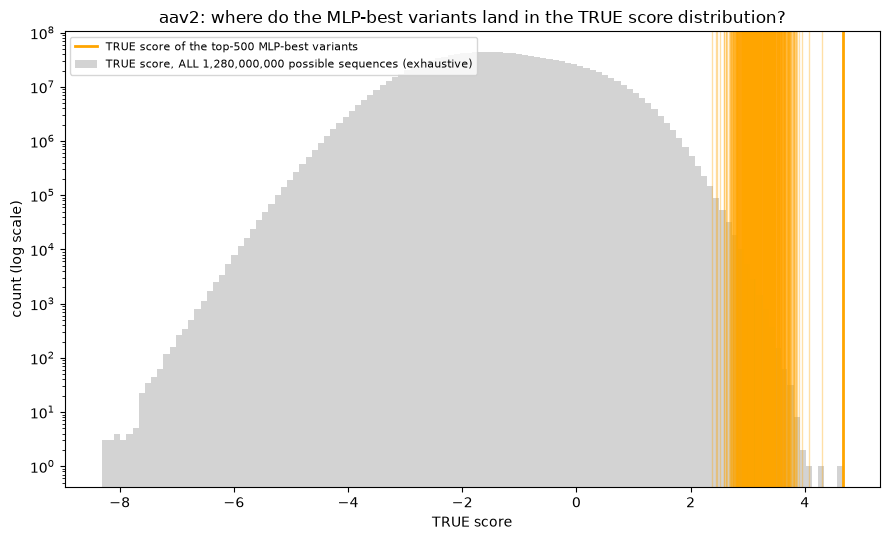

TRUE-score percentile of the MLP-best-500: median=100.00th  min=99.97th  max=100.00th

==================== aav2: TRUE-best under the MLP distribution ====================


cross-matrix scan: 100%|██████████| 64/64 [00:10<00:00,  6.24it/s]


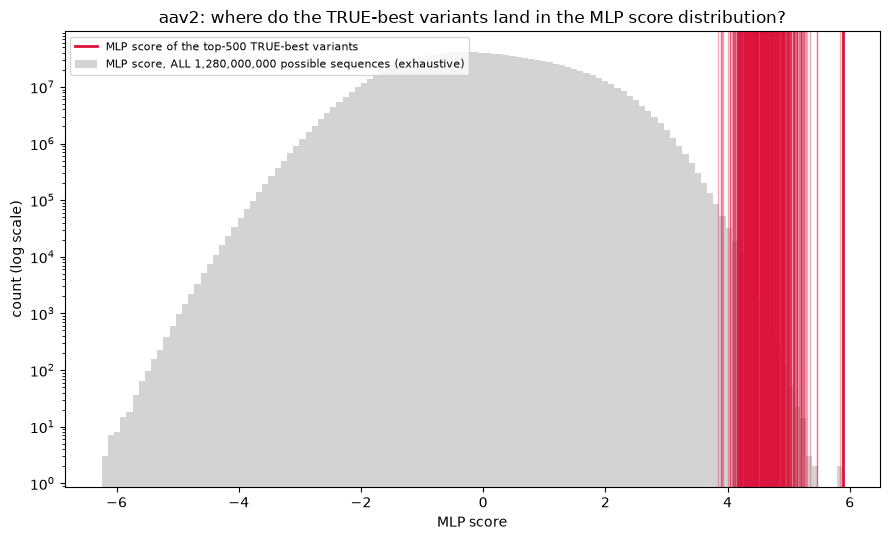

MLP-score percentile of the TRUE-best-500: median=100.00th  min=99.98th  max=100.00th


In [12]:
cross_aav2 = run_cross_matrix_check(F_ref_aav2, J_ref_aav2, F_exact_aav2, J_exact_aav2, name="aav2")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same as the "Cross-matrix check" intro above: both top-500 sets for aav5 here (MLP-best via <code>F_exact</code>/<code>J_exact</code>, TRUE-best via <code>F_viab</code>/<code>J_viab</code>) come from an exhaustive brute-force scan of all 20^7 possible sequences -- never measured, not drawn from aav5.csv.
</div>

### aav5


==================== aav5: MLP-best under the TRUE distribution ====================


cross-matrix scan: 100%|██████████| 64/64 [00:10<00:00,  6.27it/s]


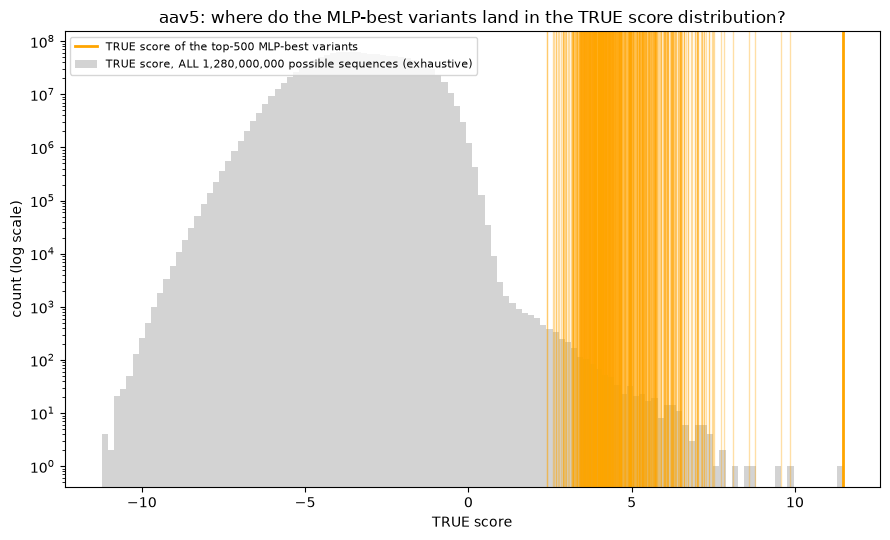

TRUE-score percentile of the MLP-best-500: median=100.00th  min=100.00th  max=100.00th

==================== aav5: TRUE-best under the MLP distribution ====================


cross-matrix scan: 100%|██████████| 64/64 [00:10<00:00,  6.19it/s]


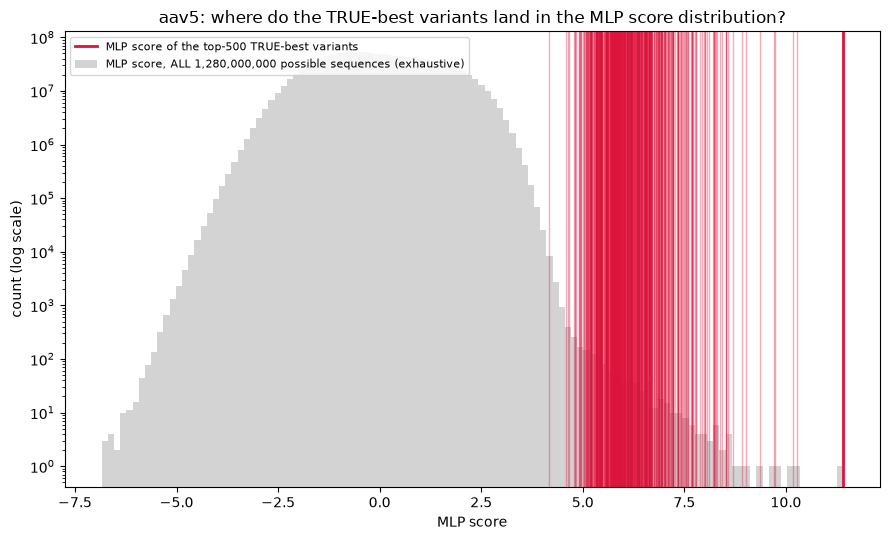

MLP-score percentile of the TRUE-best-500: median=100.00th  min=100.00th  max=100.00th


In [13]:
cross_aav5 = run_cross_matrix_check(F_ref_aav5, J_ref_aav5, F_exact_aav5, J_exact_aav5, name="aav5")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same as the "Cross-matrix check" intro above: both top-500 sets for aav9 here (MLP-best via <code>F_exact</code>/<code>J_exact</code>, TRUE-best via <code>F_viab</code>/<code>J_viab</code>) come from an exhaustive brute-force scan of all 20^7 possible sequences -- never measured, not drawn from aav9.csv.
</div>

### aav9


==================== aav9: MLP-best under the TRUE distribution ====================


cross-matrix scan: 100%|██████████| 64/64 [00:10<00:00,  6.24it/s]


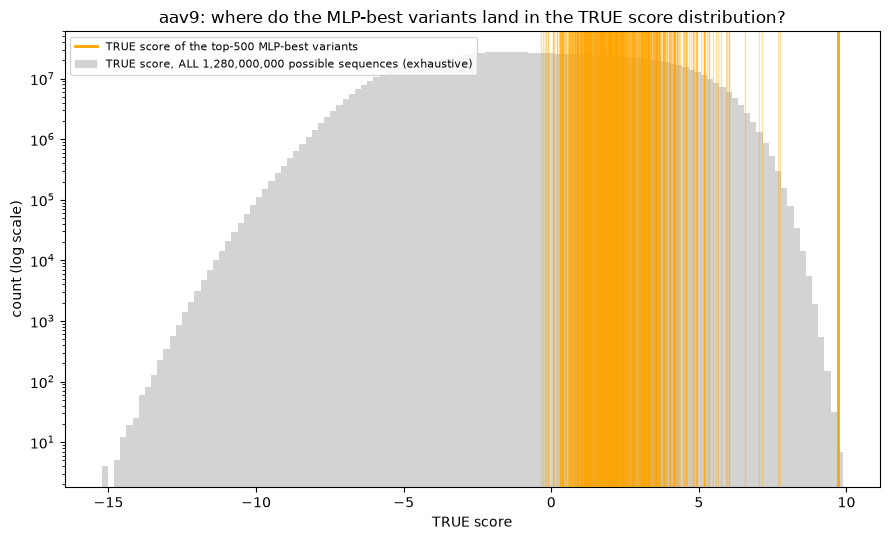

TRUE-score percentile of the MLP-best-500: median=74.23th  min=50.55th  max=100.00th

==================== aav9: TRUE-best under the MLP distribution ====================


cross-matrix scan: 100%|██████████| 64/64 [00:10<00:00,  6.31it/s]


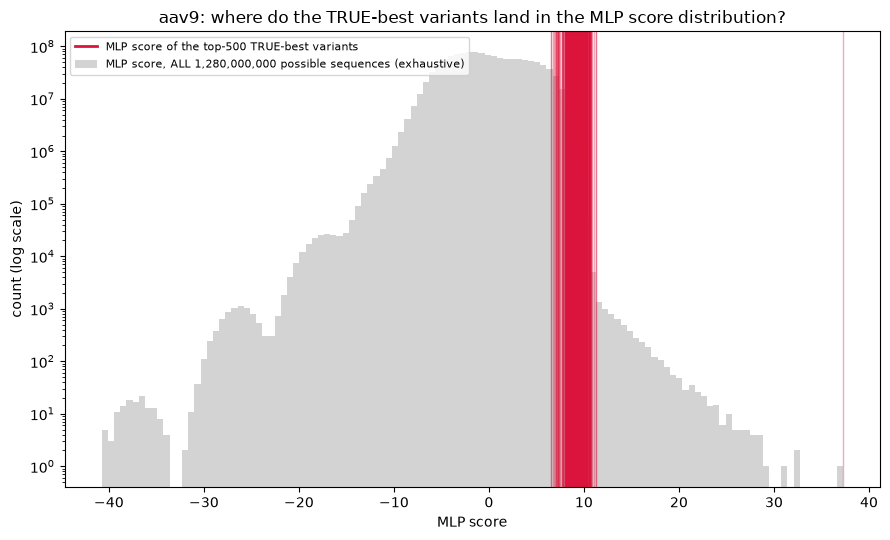

MLP-score percentile of the TRUE-best-500: median=99.80th  min=93.07th  max=100.00th


In [14]:
cross_aav9 = run_cross_matrix_check(F_ref_aav9, J_ref_aav9, F_exact_aav9, J_exact_aav9, name="aav9")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
This section reuses, unchanged, the SAME two brute-force top-500 sets from "Cross-matrix check" directly above -- <code>r1["best_seqs"]</code> = MLP-best-500 (by <code>F_exact</code>/<code>J_exact</code>) and <code>r2["best_seqs"]</code> = TRUE-best-500 (by <code>F_viab</code>/<code>J_viab</code>), both found by exhaustively scanning all 20^7 possible sequences per dataset -- and asks how many of the 500 sequences are literally identical between the two sets. This is a comparison of two purely theoretical, never-synthesized populations; it is NOT the REAL measured top-500 from the earlier aav2/aav5/aav9 sections (<code>idx_test</code>, real <code>target</code>).
</div>

## Top-500 overlap: are the TRUE-best 500 and the MLP-best 500 the SAME sequences?

`run_cross_matrix_check` above answers "does a good score under one matrix imply a good score
under the other" -- this section asks a blunter question about the two top-500 **sets**
themselves: the 500 sequences ranked best by the TRUE `F_viab`/`J_viab`, vs. the 500 sequences
ranked best by the MLP's `F_exact`/`J_exact`. **How many sequences are literally shared between
them?**

`cross_matrix_scan` already returns `best_seqs` for both directions inside `cross_aav{2,5,9}`
(`r1["best_seqs"]` = MLP-best-500, `r2["best_seqs"]` = TRUE-best-500), so this reuses that
result directly -- no new exhaustive scan needed.


In [15]:
from matplotlib.patches import Circle


def top500_overlap(cross_result, name=""):
    """cross_result: (r1, r2) as returned by run_cross_matrix_check for one dataset.
    r1['best_seqs'] = top-500 sequences ranked by the MLP's F_exact/J_exact score.
    r2['best_seqs'] = top-500 sequences ranked by the TRUE F_viab/J_viab score.
    Both are found by an exhaustive scan of the full A**L space, so within each set every
    sequence is unique -- set intersection is exact, not an approximation."""
    r1, r2 = cross_result
    mlp_top500  = {tuple(row) for row in r1["best_seqs"]}
    true_top500 = {tuple(row) for row in r2["best_seqs"]}
    shared      = mlp_top500 & true_top500
    jaccard     = len(shared) / len(mlp_top500 | true_top500)
    print(f"{name}: {len(shared)}/500 sequences ({100 * len(shared) / 500:.1f}%) are in BOTH "
          f"the TRUE-top500 and the MLP-top500 (Jaccard = {jaccard:.3f})")
    return mlp_top500, true_top500, shared


def plot_top500_venn(mlp_top500, true_top500, name="", ax=None):
    """Manual two-circle Venn diagram (fixed-size circles, not area-proportional -- no
    matplotlib_venn dependency) showing the overlap between the TRUE-top500 and MLP-top500
    sequence sets, with exact counts labeled in each region."""
    shared      = mlp_top500 & true_top500
    n_true_only = len(true_top500) - len(shared)
    n_mlp_only  = len(mlp_top500) - len(shared)
    n_shared    = len(shared)
    jaccard     = n_shared / (n_true_only + n_mlp_only + n_shared)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    r, d = 1.4, 1.1
    ax.add_patch(Circle((-d / 2, 0), r, color="tab:blue", alpha=0.4))
    ax.add_patch(Circle(( d / 2, 0), r, color="tab:red",  alpha=0.4))
    ax.text(-d / 2 - 0.7, 0, f"{n_true_only}", ha="center", va="center", fontsize=14, fontweight="bold")
    ax.text( d / 2 + 0.7, 0, f"{n_mlp_only}",  ha="center", va="center", fontsize=14, fontweight="bold")
    ax.text(0, 0, f"{n_shared}", ha="center", va="center", fontsize=16, fontweight="bold")
    ax.text(-d / 2, -r - 0.25, "TRUE-best 500\n(F_viab/J_viab)", ha="center", va="top", color="tab:blue", fontsize=9)
    ax.text( d / 2, -r - 0.25, "MLP-best 500\n(F_exact/J_exact)", ha="center", va="top", color="tab:red", fontsize=9)
    ax.set_xlim(-d / 2 - r - 0.5, d / 2 + r + 0.5); ax.set_ylim(-r - 0.9, r + 0.3)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{name}: top-500 overlap (circles not to scale)\n{n_shared}/500 shared, Jaccard={jaccard:.3f}")
    return ax


aav2: 140/500 sequences (28.0%) are in BOTH the TRUE-top500 and the MLP-top500 (Jaccard = 0.163)
aav5: 403/500 sequences (80.6%) are in BOTH the TRUE-top500 and the MLP-top500 (Jaccard = 0.675)
aav9: 1/500 sequences (0.2%) are in BOTH the TRUE-top500 and the MLP-top500 (Jaccard = 0.001)


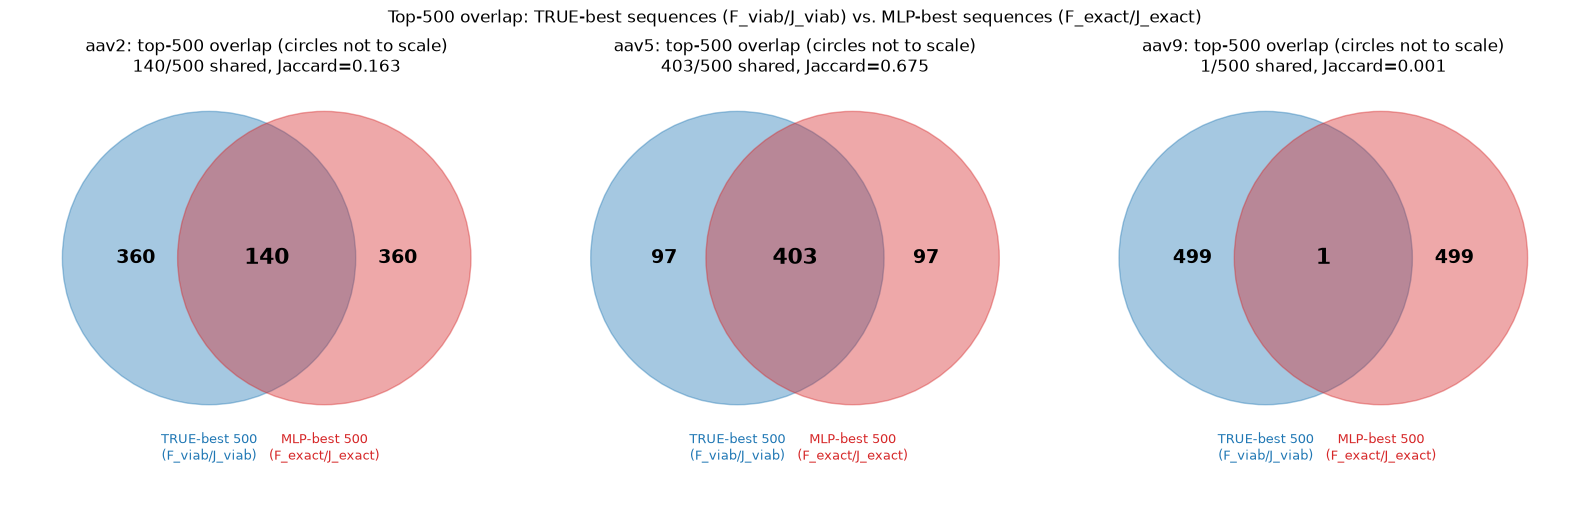

,shared,jaccard
name,,
aav2,140,0.162791
aav5,403,0.675042
aav9,1,0.001001


In [16]:
overlap_rows = []
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, cross_result, name in zip(axes, [cross_aav2, cross_aav5, cross_aav9], ["aav2", "aav5", "aav9"]):
    mlp_top500, true_top500, shared = top500_overlap(cross_result, name=name)
    plot_top500_venn(mlp_top500, true_top500, name=name, ax=ax)
    overlap_rows.append(dict(name=name, shared=len(shared),
                              jaccard=len(shared) / len(mlp_top500 | true_top500)))
fig.suptitle("Top-500 overlap: TRUE-best sequences (F_viab/J_viab) vs. MLP-best sequences (F_exact/J_exact)")
fig.tight_layout(); plt.show()

overlap_summary = pd.DataFrame(overlap_rows).set_index("name")
overlap_summary
